In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from itertools import product
import pandas as pd
import os


sns.set_theme()
sns.set_context("paper")

# This block contains a lot of functions that are commonly needed.
def write_fig(fname: str, plot):
    fig = plot.get_figure()
    dst = os.path.join("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots", f"{fname}.svg")
    # fig.savefig(dst, bbox_inches="")
    fig.savefig(dst)

def add_name_device(df: pd.DataFrame, benchmark_name: str, device: str, platform: str):
    df["benchmark_name"] = benchmark_name
    df["device"] = device
    df["platform"] = platform
    return df

The following block is used to produce the chars for Amdahl's law an and Gustavson's Law

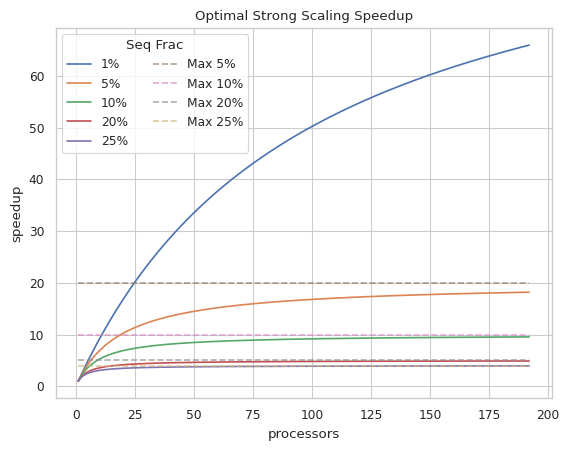

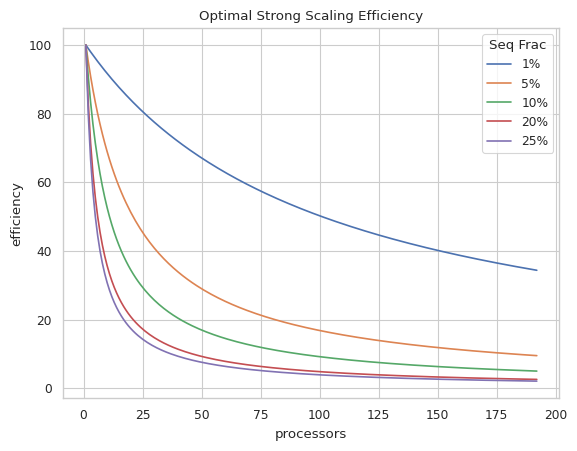

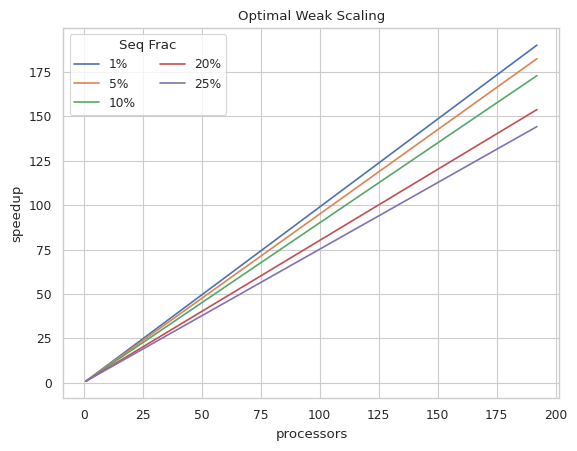

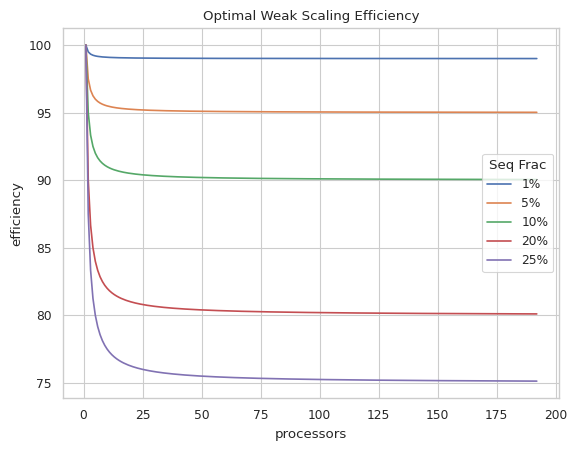

In [5]:
max_proc = 192
seq_part = [0.01, 0.05, 0.1, 0.2, 0.25]
processors = [i+1 for i in range(max_proc)]

def amdahl(s, n):
    p = 1 - s
    return 1 / (s + (p / n))

def gustavson(s, n):
    p = 1 - s
    return s + n * p

a_speedup = list(map(lambda x : {"fraction": str(int(x[0] * 100)) + "%",
                                 "processors": x[1],
                                 "speedup": amdahl(x[0], x[1])}, product(seq_part, processors)))

a_efficiency = list(map(lambda x : {"fraction": str(int(x[0] * 100)) + "%",
                                    "processors": x[1],
                                    "efficiency": (amdahl(x[0], x[1]) / x[1]) * 100}, product(seq_part, processors)))

g_speedup = list(map(lambda x : {"fraction": str(int(x[0] * 100)) + "%",
                                 "processors": x[1],
                                 "speedup": gustavson(x[0], x[1])}, product(seq_part, processors)))

g_efficiency = list(map(lambda x : {"fraction": str(int(x[0] * 100)) + "%",
                                    "processors": x[1],
                                    "efficiency": (gustavson(x[0], x[1]) / x[1]) * 100}, product(seq_part, processors)))

a_proc_df = pd.DataFrame.from_dict(a_speedup)
a_eff_df = pd.DataFrame.from_dict(a_efficiency)

g_proc_df = pd.DataFrame.from_dict(g_speedup)
g_eff_df = pd.DataFrame.from_dict(g_efficiency)

with sns.axes_style("whitegrid"):
    # lp = sns.lineplot(x=processors, y=processors, label="0% - ideal")
    lp = sns.lineplot(data=a_proc_df, x="processors", y="speedup", hue="fraction")

    # Add asymptotes
    for s in seq_part[1:]:
        sns.lineplot(x=processors, y=[1/s] * max_proc, legend=True, alpha=0.7, linestyle="--", label=f"Max {str(int(s*100))}%")

    plt.legend(title="Seq Frac")
    plt.title("Optimal Strong Scaling Speedup")
    # sns.move_legend(lp, loc="upper left", ncol=2, bbox_to_anchor=(1,1))
    sns.move_legend(lp, loc="upper left", ncol=2)

    write_fig("00_amdal_speedup", lp)
plt.show()

with sns.axes_style("whitegrid"):
    lp = sns.lineplot(data=a_eff_df, x="processors", y="efficiency", hue="fraction", )

    plt.title("Optimal Strong Scaling Efficiency")
    plt.legend(title="Seq Frac")

    write_fig("01_amdal_efficiency", lp)
plt.show()

with sns.axes_style("whitegrid"):
    # lp = sns.lineplot(x=processors, y=processors, label="0% - ideal")
    lp = sns.lineplot(data=g_proc_df, x="processors", y="speedup", hue="fraction")

    # Add asymptotes
    # for s in seq_part[1:]:
    #     sns.lineplot(x=processors, y=[1/s] * max_proc, legend=True, alpha=0.7, linestyle="--", label=f"Max {str(int(s*100))}%")

    plt.legend(title="Seq Frac")
    plt.title("Optimal Weak Scaling")
    # sns.move_legend(lp, loc="upper left", ncol=2, bbox_to_anchor=(1,1))
    sns.move_legend(lp, loc="upper left", ncol=2)

    write_fig("02_gustavson_speedup", lp)
plt.show()

with sns.axes_style("whitegrid"):
    lp = sns.lineplot(data=g_eff_df, x="processors", y="efficiency", hue="fraction", )

    plt.title("Optimal Weak Scaling Efficiency")
    plt.legend(title="Seq Frac")

    # Asymptots are obvious enough.
    # for s in seq_part:
    #     sns.lineplot(x=processors, y=[100*(1-s)] * max_proc, legend=True, alpha=0.7, linestyle="--", label=f"Max {str(int(s*100))}%")

    write_fig("03_gustavson_efficiency", lp)
plt.show()



Generate Dimension Input for Benchmarks

In [6]:
print("CPU Small")
print(" ".join([str(int(2 ** (0.5 * i))) for i in range(12, 19)]))
print()

print("CPU Medium")
print(" ".join([str(int(2 ** (0.5 * i))) for i in range(18, 25)]))
print()

print("CPU Large")
print(" ".join([str(int(2 ** (0.5 * i))) for i in range(24, 29)]))
print()

print("GPU PC")
print(" ".join([str(int(2 ** (0.5 * i))) for i in range(12, 25)]))
print()

print("GPU Cluster")
print(" ".join([str(int(2 ** (0.5 * i))) for i in range(12, 31)]))
print()

print("Cache Samples")
print(" ".join([str(i) for i in range(16, 1536, 16)]))
print()

print(f"Cache B Samples")
print(" ".join([str(i) for i in range(16, 129, 8)]))
print()

CPU Small
64 90 128 181 256 362 512

CPU Medium
512 724 1024 1448 2048 2896 4096

CPU Large
4096 5792 8192 11585 16384

GPU PC
64 90 128 181 256 362 512 724 1024 1448 2048 2896 4096

GPU Cluster
64 90 128 181 256 362 512 724 1024 1448 2048 2896 4096 5792 8192 11585 16384 23170 32768

Cache Samples
16 32 48 64 80 96 112 128 144 160 176 192 208 224 240 256 272 288 304 320 336 352 368 384 400 416 432 448 464 480 496 512 528 544 560 576 592 608 624 640 656 672 688 704 720 736 752 768 784 800 816 832 848 864 880 896 912 928 944 960 976 992 1008 1024 1040 1056 1072 1088 1104 1120 1136 1152 1168 1184 1200 1216 1232 1248 1264 1280 1296 1312 1328 1344 1360 1376 1392 1408 1424 1440 1456 1472 1488 1504 1520

Cache B Samples
16 24 32 40 48 56 64 72 80 88 96 104 112 120 128



Plot to visualize the difference between ram and pci-e bandwidth

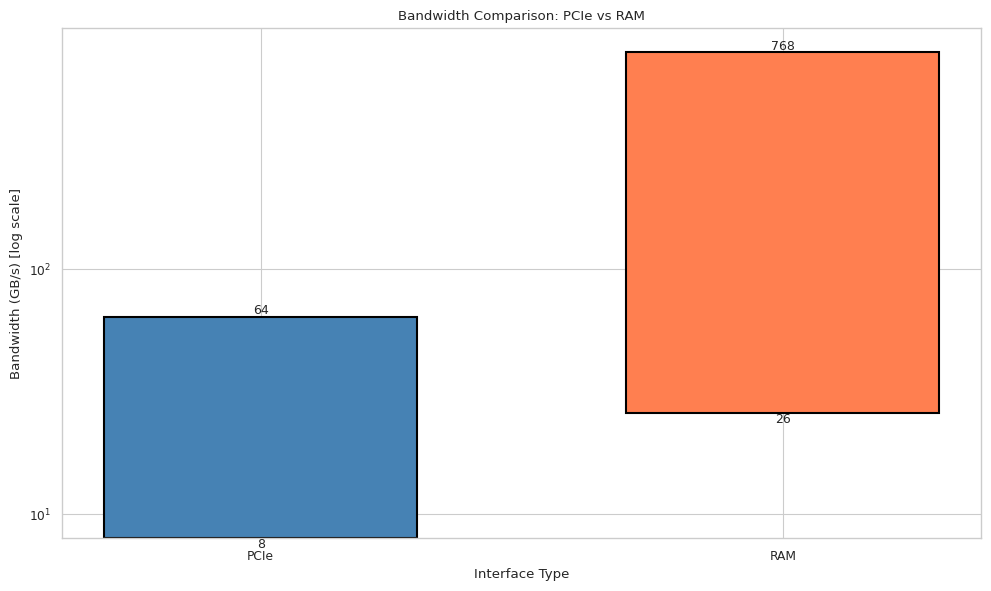

In [7]:
summary_data = {
    'Interface': ['PCIe', 'RAM'],
    'Min': [8, 26],
    'Max': [64, 768]
}

summary_df = pd.DataFrame(summary_data)
sns.set_context("paper")

with sns.axes_style("whitegrid"):
    fig = plt.figure(figsize=(10, 6))

    # Create bars from min to max
    for i, row in summary_df.iterrows():
        plt.bar(i, row['Max'] - row['Min'],
                bottom=row['Min'],
                width=0.6,
                color=['steelblue', 'coral'][i],
                edgecolor='black',
                linewidth=1.5)

    plt.yscale('log')
    plt.xticks([0, 1], summary_df['Interface'])
    plt.ylabel('Bandwidth (GB/s) [log scale]')
    plt.xlabel('Interface Type')
    plt.title('Bandwidth Comparison: PCIe vs RAM')

    # Add min/max labels
    for i, row in summary_df.iterrows():
        plt.text(i, row['Min'], f"{row['Min']}",
                ha='center', va='top', fontsize=9)
        plt.text(i, row['Max'], f"{row['Max']}",
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    write_fig("04_bandwidth-delta", fig)
    plt.show()


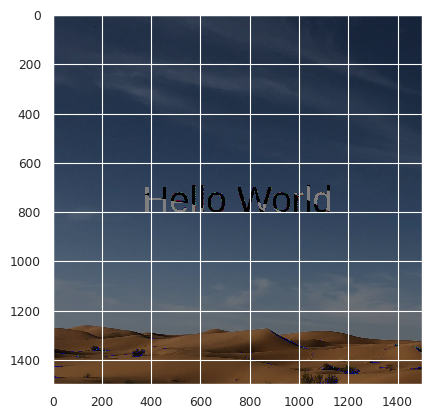

In [8]:
# Picture Merge
from PIL import Image
import numpy as np

desert_pil = Image.open("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/pexels-greg-gulik-349419-1001435.jpg")
zebra_pil = Image.open("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/Zebra_print_2.jpg")
text_pil = Image.open("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/text.png")


white = np.full((1500, 1500, 3), 255, dtype=np.uint8)
desert_np = np.array(desert_pil)[:1500, :1500,:]
zebra_np = np.array(zebra_pil)[:,:,:1]
text_np = np.array(text_pil)[:,:,:1]

text_over_desert = desert_np.copy()
plt.imshow(desert_np, interpolation="nearest")

out_simple = white - (text_over_desert * text_np) + (white - text_np)
out_complex_fp = (white - (text_over_desert * text_np) + (white - zebra_np) * (white - text_np)) / 2
out_complex = out_complex_fp.astype(np.uint8)

img = Image.fromarray(out_simple)
img.save("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/simple.png")

img2 = Image.fromarray(out_complex)
img2.save("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/complex.png")

img3 = Image.fromarray(desert_np)
img3.save("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/desert_crop.png")

img4 = Image.fromarray(white - text_np)
img4.save("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/text_inverted.png")

img5 = Image.fromarray(white - zebra_np)
img5.save("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/zebra_inverted.png")


# plt.imshow(out_simple, interpolation="nearest")
# plt.imshow(out_complex, interpolation="nearest")


Index(['cpu_count', 'module', 'benchmark_type', 'max_iter', 'nx', 'ny',
       'cache_bs_1', 'cache_bs_2', 'iter_unrol', 'sample', 'duration',
       'normalized_duration', 'name', 'benchmark_name', 'device', 'platform',
       'group-cpu-nx-ny', 'group-module-nx-ny', 'dim', 'group-module-cpu'],
      dtype='object')


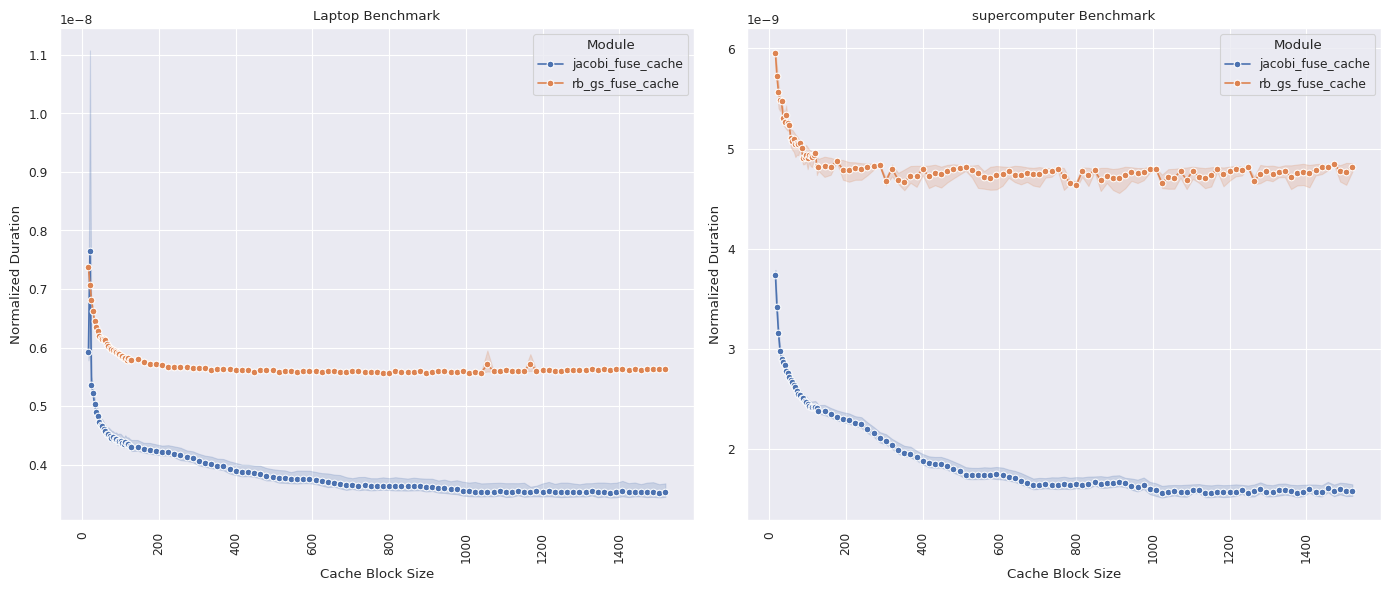

In [42]:
from benchmark import results_processing as rp

laptop_cache = [
    "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/caching_1/laptop/pcbm_20251127-210820_KZLN37DcdxasRrNFAXuIFlAfd7JsxbDXD7iXi0hPxdA=.json",
    "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/caching_1/laptop/pcbm_20251128-053237_txfW8CXpowin3L_35_o13fiI52bn0j620XVdmi3qTek=.json"
]

supercomputer_cache = [
    "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/caching_1/piora/pcbm_20251127-144737_jyUj7KY1q_dp-POLlhXbcuq4x3oCcgoYnbH0zbWd7gk=.json",
    "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/caching_1/piora/pcbm_20251127-204632_JlFhB5nK2w5HZx-pWIhcDndJgiSmMeJ6_DIthOGaBL8=.json"
]

laptop_caches = pd.concat(list(map(lambda p : rp.create_dataframe(rp.load_benchmark_run(p)), laptop_cache)), ignore_index=True)
supercomputer_caches = pd.concat(list(map(lambda p : rp.create_dataframe(rp.load_benchmark_run(p)), supercomputer_cache)), ignore_index=True)


fully_augmented = rp.augment_df(pd.concat([add_name_device(df=laptop_caches,
                                                           device="cpu",
                                                           benchmark_name="laptop", platform="laptop"),
                                           add_name_device(df=supercomputer_caches,
                                                           device="cpu",
                                                           benchmark_name="supercomputer", platform="supercomputer")], ignore_index=True))

print(fully_augmented.columns)

# Create Dual Plot for Pandas
# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First plot: laptop data
laptop_data1 = fully_augmented[fully_augmented['benchmark_name'] == 'laptop']
laptop_data =  laptop_data1[laptop_data1['module'] != "jacobi_fuse_cache_unroll_jitter"]
sns.lineplot(data=laptop_data, x='cache_bs_1', y='normalized_duration',
             hue='module', marker='o', ax=axes[0])
axes[0].set_title('Laptop Benchmark')
axes[0].set_xlabel('Cache Block Size')
axes[0].set_ylabel('Normalized Duration')
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(title='Module')

# Second plot: supercomputer data
supercomputer_data1 = fully_augmented[fully_augmented['benchmark_name'] == 'supercomputer']
supercomputer_data = supercomputer_data1[supercomputer_data1["module"] != "jacobi_fuse_cache_unroll_jitter"]
sns.lineplot(data=supercomputer_data, x='cache_bs_1', y='normalized_duration',
             hue='module', marker='o', ax=axes[1])
axes[1].set_title('supercomputer Benchmark')
axes[1].set_xlabel('Cache Block Size')
axes[1].set_ylabel('Normalized Duration')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend(title='Module')

plt.tight_layout()
plt.show()


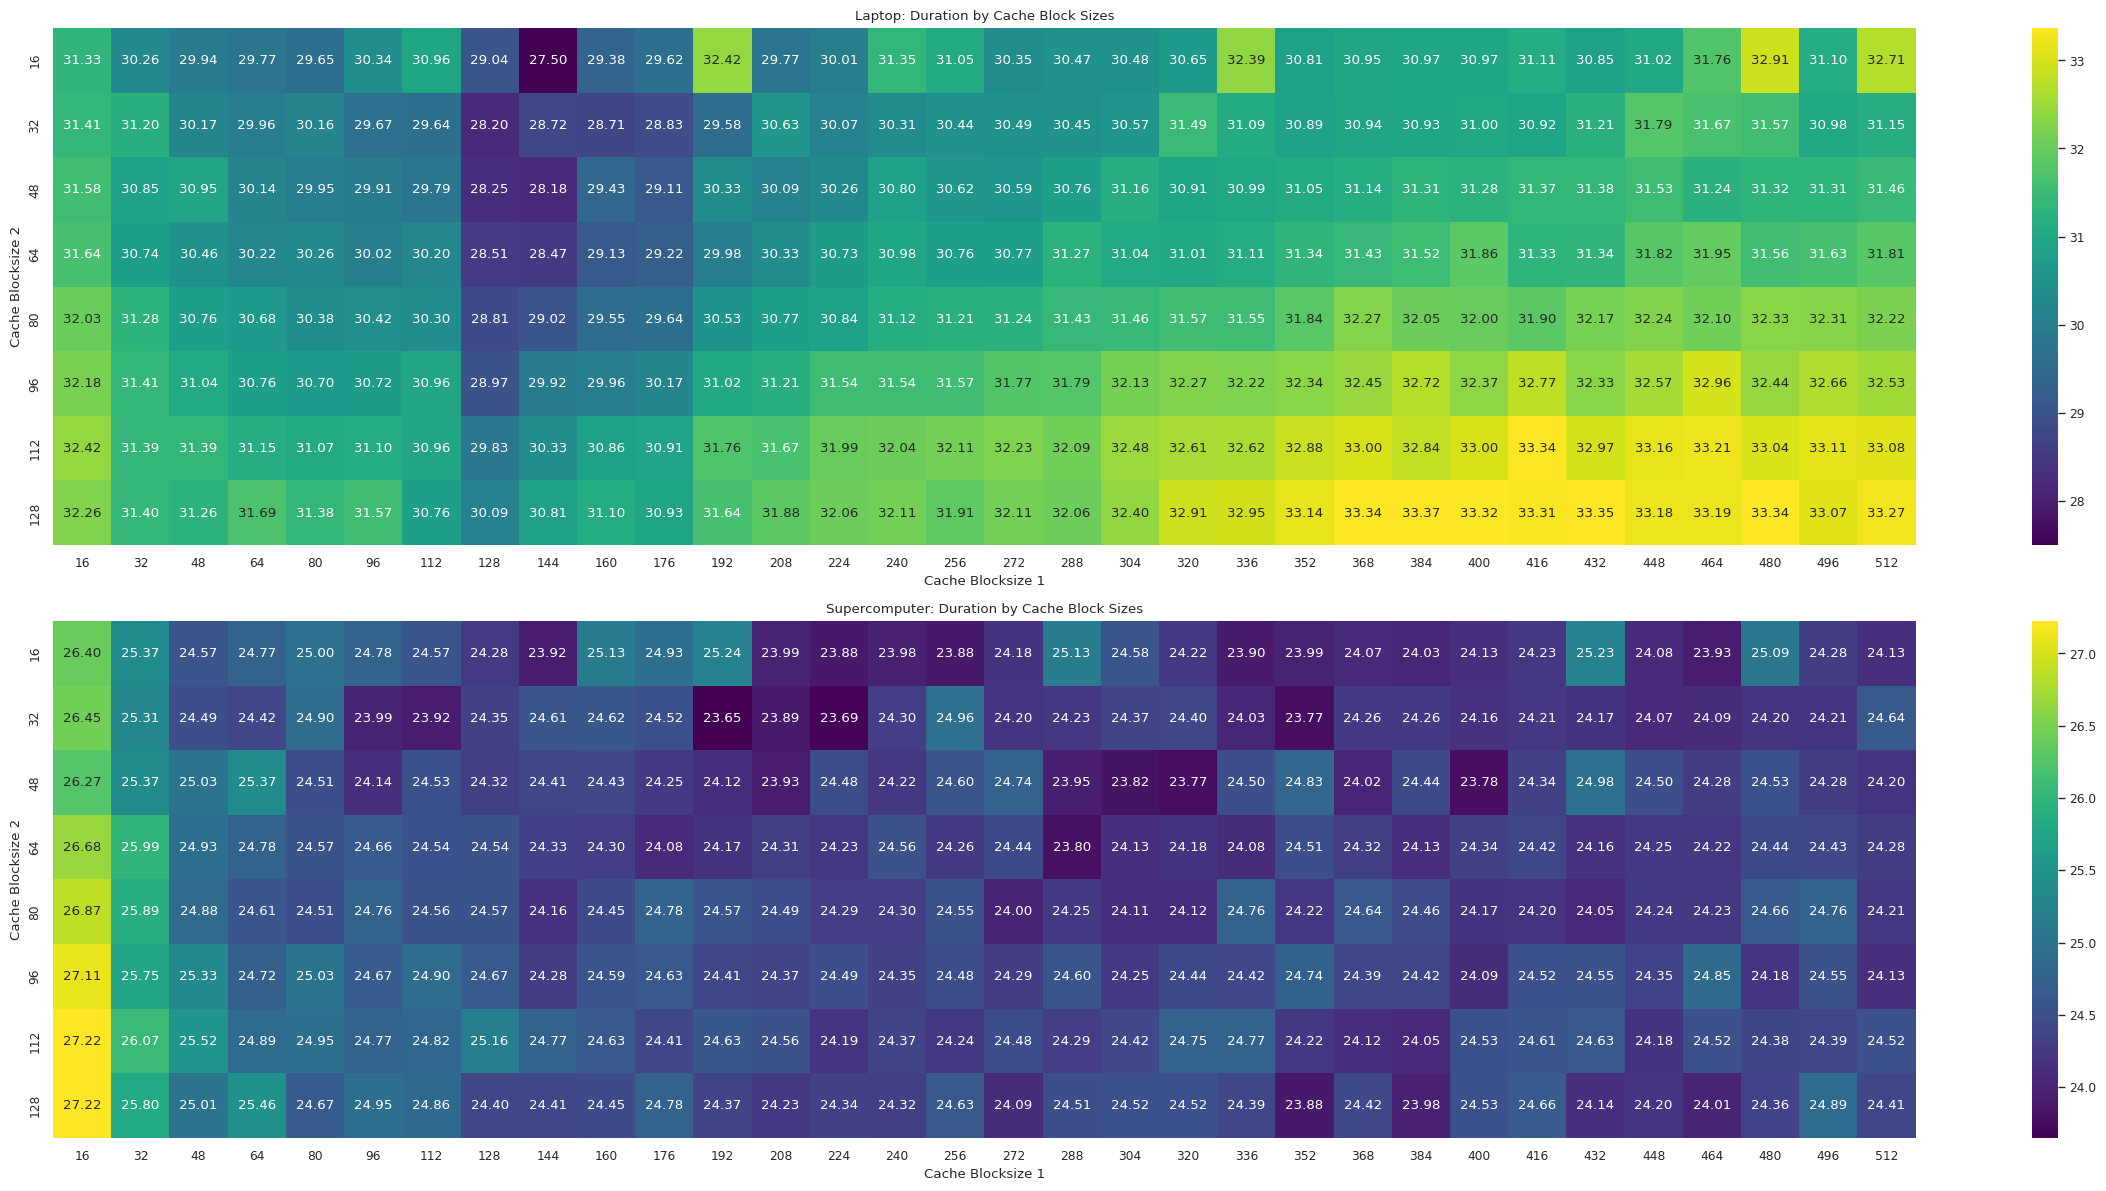

In [43]:
# Filter data for the specific module
data_2d = fully_augmented[fully_augmented['module'] == "jacobi_fuse_cache_unroll_jitter"]

with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(2, 1, figsize=(24, 12))

    # First heatmap: laptop
    laptop_data = data_2d[data_2d["benchmark_name"] == "laptop"]
    heatmap_laptop = laptop_data.pivot_table(index='cache_bs_2',
                                              columns='cache_bs_1',
                                              values='duration',
                                              aggfunc='mean')

    sns.heatmap(heatmap_laptop, annot=True, fmt='.2f', cmap='viridis', ax=axes[0])
    axes[0].set_title('Laptop: Duration by Cache Block Sizes')
    axes[0].set_xlabel('Cache Blocksize 1')
    axes[0].set_ylabel('Cache Blocksize 2')

    # Second heatmap: supercomputer
    supercomputer_data = data_2d[data_2d["benchmark_name"] == "supercomputer"]
    heatmap_supercomputer = supercomputer_data.pivot_table(index='cache_bs_2',
                                                            columns='cache_bs_1',
                                                            values='duration',
                                                            aggfunc='mean')

    sns.heatmap(heatmap_supercomputer, annot=True, fmt='.2f', cmap='viridis', ax=axes[1])
    axes[1].set_title('Supercomputer: Duration by Cache Block Sizes')
    axes[1].set_xlabel('Cache Blocksize 1')
    axes[1].set_ylabel('Cache Blocksize 2')

    plt.tight_layout()
    plt.show()

Scaling Benchmarks Preparation

In [48]:
import os
from benchmark import results_processing as rp
cpu_laptop = ["/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_1/laptop/pcbm_20251127-153037_MHgUgPYt5tCihLSqLL9nSZXNz7ZZjQFh-Nsa7KOYkNc=.json",
              "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_1/laptop/pcbm_20251127-153332_mZeAvqVX_O53jIPeJwqdT0bPl-ZXYsr90tQsn7dIzwI=.json",
              "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_1/laptop/pcbm_20251127-154324_EPLYGVELhXVYFo9EM7_U9pf7L3WJsHQ1pIqAMK2Uy6Y=.json"]
gpu_laptop = ["/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_1/laptop/pcbm_20251127-160010_NEK8oOQ2-XLdzomJbC39wxfFEHOBTt5M2lgYJWyGbI4=.json",
              "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_1/laptop/pcbm_20251127-160135_5j6SaODlr0CSo7Ls-YaYC8WG7CTpURBFLMS3VUu8SAM=.json",
              "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_1/laptop/pcbm_20251127-160300_1u3NWcwX6rP1ApkMruK4vB73joxtuL_0t0J14cqkm5Q=.json"]
cpu_supercomputer = ["/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_2/piora/pcbm_20251128-190713_gWp4hM0od0AieTmlmzMmu0mhkiJ-dzcELCLlPGpyOtA=.json",
                     "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_2/piora/pcbm_20251128-191131_cFRaoY9dQXBptctF5ytNHypsJxSs_UmU3bgueEJpCZg=.json",
                     "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_2/piora/pcbm_20251128-192303_dzsgPNqfP0ZXwyMNv43zm9LaCLcFs6xj0r4mg-St3Pk=.json"]
gpu_supercomputer = ["/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_2/piora/pcbm_20251128-200811_-earz9NvDQ3cz_sOjgWdvsMYHb1eqtfVoewINkbHuU0=.json",
                     "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_2/piora/pcbm_20251128-200934_-yinb2qMe4CWTs9eF7C2BHNtJ3mB0t5dcxL4REF72BY=.json",
                     "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_2/piora/pcbm_20251128-201042_TsUiuPR7slc9rPaFpfrf_69sRQs14ort7A_gok6M85M=.json"]

cpu_small_laptop, cpu_medium_laptop, cpu_large_laptop = list(map(lambda p: rp.create_dataframe(rp.load_benchmark_run(path=p)), cpu_laptop))
gpu_small_laptop, gpu_medium_laptop, gpu_large_laptop = list(map(lambda p: rp.create_dataframe(rp.load_benchmark_run(path=p)), gpu_laptop))
cpu_small_supercomputer, cpu_medium_supercomputer, cpu_large_supercomputer = list(map(lambda p: rp.create_dataframe(rp.load_benchmark_run(path=p)), cpu_supercomputer))
gpu_small_supercomputer, gpu_medium_supercomputer, gpu_large_supercomputer = list(map(lambda p: rp.create_dataframe(rp.load_benchmark_run(path=p)), gpu_supercomputer))

# Add columns for easier identification
cpu_small_laptop = add_name_device(cpu_small_laptop, benchmark_name="cpu_small_laptop", device="cpu", platform="laptop")
cpu_medium_laptop = add_name_device(cpu_medium_laptop, benchmark_name="cpu_medium_laptop", device="cpu", platform="laptop")
cpu_large_laptop = add_name_device(cpu_large_laptop, benchmark_name="cpu_large_laptop", device="cpu", platform="laptop")

gpu_small_laptop = add_name_device(gpu_small_laptop, benchmark_name="gpu_small_laptop", device="gpu", platform="laptop")
gpu_medium_laptop = add_name_device(gpu_medium_laptop, benchmark_name="gpu_medium_laptop", device="gpu", platform="laptop")
gpu_large_laptop = add_name_device(gpu_large_laptop, benchmark_name="gpu_large_laptop", device="gpu", platform="laptop")

laptop_scaling = pd.concat([cpu_small_laptop, cpu_medium_laptop, cpu_large_laptop, gpu_small_laptop,  gpu_medium_laptop, gpu_large_laptop], ignore_index=True)
laptop_scaling = rp.augment_df(laptop_scaling)

# Here the issue seems to take hold
cpu_small_supercomputer = add_name_device(cpu_small_supercomputer, benchmark_name="cpu_small_supercomputer", device="cpu", platform="supercomputer")
cpu_medium_supercomputer = add_name_device(cpu_medium_supercomputer, benchmark_name="cpu_medium_supercomputer", device="cpu", platform="supercomputer")
cpu_large_supercomputer = add_name_device(cpu_large_supercomputer, benchmark_name="cpu_large_supercomputer", device="cpu", platform="supercomputer")

gpu_small_supercomputer = add_name_device(gpu_small_supercomputer, benchmark_name="gpu_small_supercomputer", device="gpu", platform="supercomputer")
gpu_medium_supercomputer = add_name_device(gpu_medium_supercomputer, benchmark_name="gpu_medium_supercomputer", device="gpu", platform="supercomputer")
gpu_large_supercomputer = add_name_device(gpu_large_supercomputer, benchmark_name="gpu_large_supercomputer", device="gpu", platform="supercomputer")

supercomputer_scaling = pd.concat([cpu_small_supercomputer, cpu_medium_supercomputer, cpu_large_supercomputer, gpu_small_supercomputer,  gpu_medium_supercomputer, gpu_large_supercomputer], ignore_index=True)
supercomputer_scaling = rp.augment_df(supercomputer_scaling)


joint_df = pd.concat([laptop_scaling, supercomputer_scaling], ignore_index=True)

print(joint_df.columns)

/tmp/ipykernel_6772/1895459899.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  laptop_scaling = pd.concat([cpu_small_laptop, cpu_medium_laptop, cpu_large_laptop, gpu_small_laptop,  gpu_medium_laptop, gpu_large_laptop], ignore_index=True)
/tmp/ipykernel_6772/1895459899.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  supercomputer_scaling = pd.concat([cpu_small_supercomputer, cpu_medium_supercomputer, cpu_large_supercomputer, gpu_small_supercomputer,  gpu_medium_supercomputer, gpu_large_

Index(['cpu_count', 'module', 'benchmark_type', 'max_iter', 'nx', 'ny',
       'cache_bs_1', 'cache_bs_2', 'iter_unrol', 'sample', 'duration',
       'normalized_duration', 'name', 'benchmark_name', 'device', 'platform',
       'group-cpu-nx-ny', 'group-module-nx-ny', 'dim', 'group-module-cpu'],
      dtype='object')


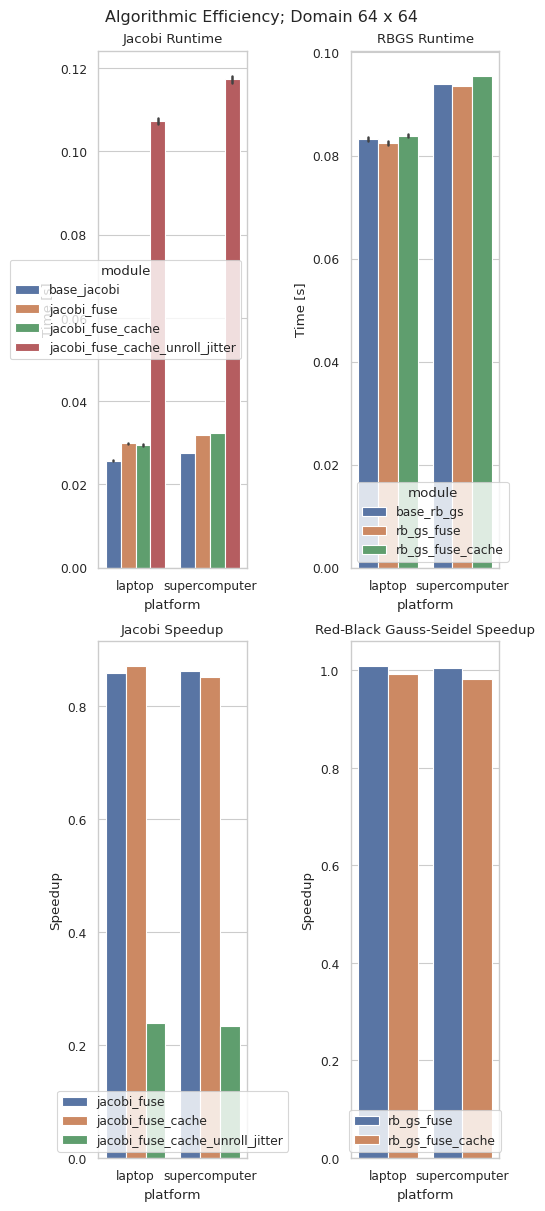

In [70]:
# Plot for algorithmic efficiency. SIZE 64 x 64
algo_eff_dataframe_all = joint_df.query("nx == 64 and ny == 64 and device == 'cpu' and cpu_count == 1")

jacobi_modules = [
    "base_jacobi",
    "jacobi_fuse",
    "jacobi_fuse_cache",
    "jacobi_fuse_cache_unroll_jitter",
]

rbgs_modules = [
    "base_rb_gs",
    "rb_gs_fuse",
    "rb_gs_fuse_cache",
]

# Identify platform
laptop_benchmarks = ["cpu_small_laptop", "cpu_medium_laptop"]
super_benchmarks = ["cpu_small_supercomputer", "cpu_medium_supercomputer"]


algo_eff_dataframe_jacobi = algo_eff_dataframe_all[algo_eff_dataframe_all["module"].isin(jacobi_modules)].copy()
algo_eff_dataframe_rb_gs = algo_eff_dataframe_all[algo_eff_dataframe_all["module"].isin(rbgs_modules)].copy()

# Average duration per module × benchmark
avg_df = (
    algo_eff_dataframe_all[
        algo_eff_dataframe_all["module"].isin(jacobi_modules + rbgs_modules)
    ]
    .groupby(["module", "benchmark_name", "platform"])["duration"]
    .mean()
    .reset_index()
)

avg_df = avg_df.dropna(subset=["platform"])

# ------------------ Jacobi speedups ------------------
jacobi_df = avg_df[avg_df["module"].isin(jacobi_modules)].copy()
base_jacobi = jacobi_df[jacobi_df["module"] == "base_jacobi"] \
    .set_index("platform")["duration"]

jacobi_df["speedup"] = jacobi_df.apply(
    lambda r: base_jacobi[r["platform"]] / r["duration"], axis=1
)
jacobi_df_plot = jacobi_df[jacobi_df["module"] != "base_jacobi"]

# ------------------ RBGS speedups ------------------
rbgs_df = avg_df[avg_df["module"].isin(rbgs_modules)].copy()
base_rbgs = rbgs_df[rbgs_df["module"] == "base_rb_gs"] \
    .set_index("platform")["duration"]

rbgs_df["speedup"] = rbgs_df.apply(
    lambda r: base_rbgs[r["platform"]] / r["duration"], axis=1
)
rbgs_df_plot = rbgs_df[rbgs_df["module"] != "base_rb_gs"]

# Algo eff in speedup:
# ---------------------------------------------------------
# Compute speedups of base_jacobi / base_rb_gs vs optimized
# (excluding *_fuse_cache_jitter variants)
# ---------------------------------------------------------

with sns.axes_style("whitegrid"):

# ------------------ Plotting ------------------
    fig, axes = plt.subplots(2, 2, figsize=(5, 12), constrained_layout=True)
    fig.suptitle("Algorithmic Efficiency; Domain 64 x 64")

    sns.barplot(
        data=algo_eff_dataframe_jacobi,
    hue="module", y="duration", x="platform",
        ax=axes[0, 0]
    )
    axes[0, 0].set_title("Jacobi Runtime")
    axes[0, 0].set_ylabel("Time [s]")
    # axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=90)

    sns.barplot(
        data=algo_eff_dataframe_rb_gs,
        hue="module", y="duration", x="platform",
        ax=axes[0, 1]
    )
    axes[0, 1].set_title("RBGS Runtime")
    axes[0, 1].set_ylabel("Time [s]")
    # axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=90)

    sns.barplot(
        data=jacobi_df_plot,
        hue="module", y="speedup", x="platform",
        ax=axes[1, 0]
    )
    axes[1, 0].set_title("Jacobi Speedup")
    axes[1, 0].set_ylabel("Speedup")
    axes[1, 0].legend(loc="lower center")
    # axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)

    sns.barplot(
        data=rbgs_df_plot,
        hue="module", y="speedup", x="platform",
        ax=axes[1, 1]
    )
    axes[1, 1].set_title("Red-Black Gauss-Seidel Speedup")
    axes[1, 1].set_ylabel("Speedup")
    axes[1, 1].legend(loc="lower center")
    # axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)

    write_fig(plot=fig, fname="081_algo_eff_64")
    plt.show()

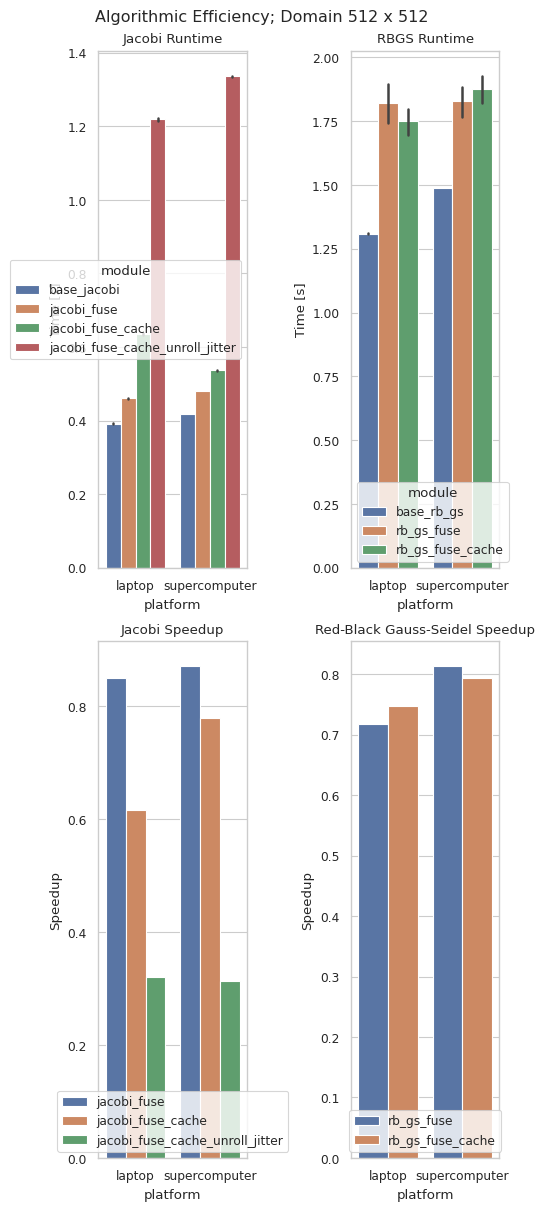

In [69]:
# Plot for algorithmic efficiency. SIZE 515 x 512
algo_eff_dataframe_all = joint_df.query("nx == 512 and ny == 512 and device == 'cpu' and cpu_count == 1")

jacobi_modules = [
    "base_jacobi",
    "jacobi_fuse",
    "jacobi_fuse_cache",
    "jacobi_fuse_cache_unroll_jitter",
]

rbgs_modules = [
    "base_rb_gs",
    "rb_gs_fuse",
    "rb_gs_fuse_cache",
]

# Identify platform
laptop_benchmarks = ["cpu_small_laptop", "cpu_medium_laptop"]
super_benchmarks = ["cpu_small_supercomputer", "cpu_medium_supercomputer"]


algo_eff_dataframe_jacobi = algo_eff_dataframe_all[algo_eff_dataframe_all["module"].isin(jacobi_modules)].copy()
algo_eff_dataframe_rb_gs = algo_eff_dataframe_all[algo_eff_dataframe_all["module"].isin(rbgs_modules)].copy()

# Average duration per module × benchmark
avg_df = (
    algo_eff_dataframe_all[
        algo_eff_dataframe_all["module"].isin(jacobi_modules + rbgs_modules)
    ]
    .groupby(["module", "benchmark_name", "platform"])["duration"]
    .mean()
    .reset_index()
)

avg_df = avg_df.dropna(subset=["platform"])

# ------------------ Jacobi speedups ------------------
jacobi_df = avg_df[avg_df["module"].isin(jacobi_modules)].copy()
base_jacobi = jacobi_df[jacobi_df["module"] == "base_jacobi"] \
    .set_index("platform")["duration"]

jacobi_df["speedup"] = jacobi_df.apply(
    lambda r: base_jacobi[r["platform"]] / r["duration"], axis=1
)
jacobi_df_plot = jacobi_df[jacobi_df["module"] != "base_jacobi"]

# ------------------ RBGS speedups ------------------
rbgs_df = avg_df[avg_df["module"].isin(rbgs_modules)].copy()
base_rbgs = rbgs_df[rbgs_df["module"] == "base_rb_gs"] \
    .set_index("platform")["duration"]

rbgs_df["speedup"] = rbgs_df.apply(
    lambda r: base_rbgs[r["platform"]] / r["duration"], axis=1
)
rbgs_df_plot = rbgs_df[rbgs_df["module"] != "base_rb_gs"]

# Algo eff in speedup:
# ---------------------------------------------------------
# Compute speedups of base_jacobi / base_rb_gs vs optimized
# (excluding *_fuse_cache_jitter variants)
# ---------------------------------------------------------

with sns.axes_style("whitegrid"):

# ------------------ Plotting ------------------
    fig, axes = plt.subplots(2, 2, figsize=(5, 12), constrained_layout=True)
    fig.suptitle("Algorithmic Efficiency; Domain 512 x 512")

    sns.barplot(
        data=algo_eff_dataframe_jacobi,
    hue="module", y="duration", x="platform",
        ax=axes[0, 0]
    )
    axes[0, 0].set_title("Jacobi Runtime")
    axes[0, 0].set_ylabel("Time [s]")
    # axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=90)

    sns.barplot(
        data=algo_eff_dataframe_rb_gs,
        hue="module", y="duration", x="platform",
        ax=axes[0, 1]
    )
    axes[0, 1].set_title("RBGS Runtime")
    axes[0, 1].set_ylabel("Time [s]")
    # axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=90)

    sns.barplot(
        data=jacobi_df_plot,
        hue="module", y="speedup", x="platform",
        ax=axes[1, 0]
    )
    axes[1, 0].set_title("Jacobi Speedup")
    axes[1, 0].set_ylabel("Speedup")
    axes[1, 0].legend(loc="lower center")
    # axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)

    sns.barplot(
        data=rbgs_df_plot,
        hue="module", y="speedup", x="platform",
        ax=axes[1, 1]
    )
    axes[1, 1].set_title("Red-Black Gauss-Seidel Speedup")
    axes[1, 1].set_ylabel("Speedup")
    axes[1, 1].legend(loc="lower center")
    # axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)

    write_fig(plot=fig, fname="082_algo_eff_512")
    plt.show()


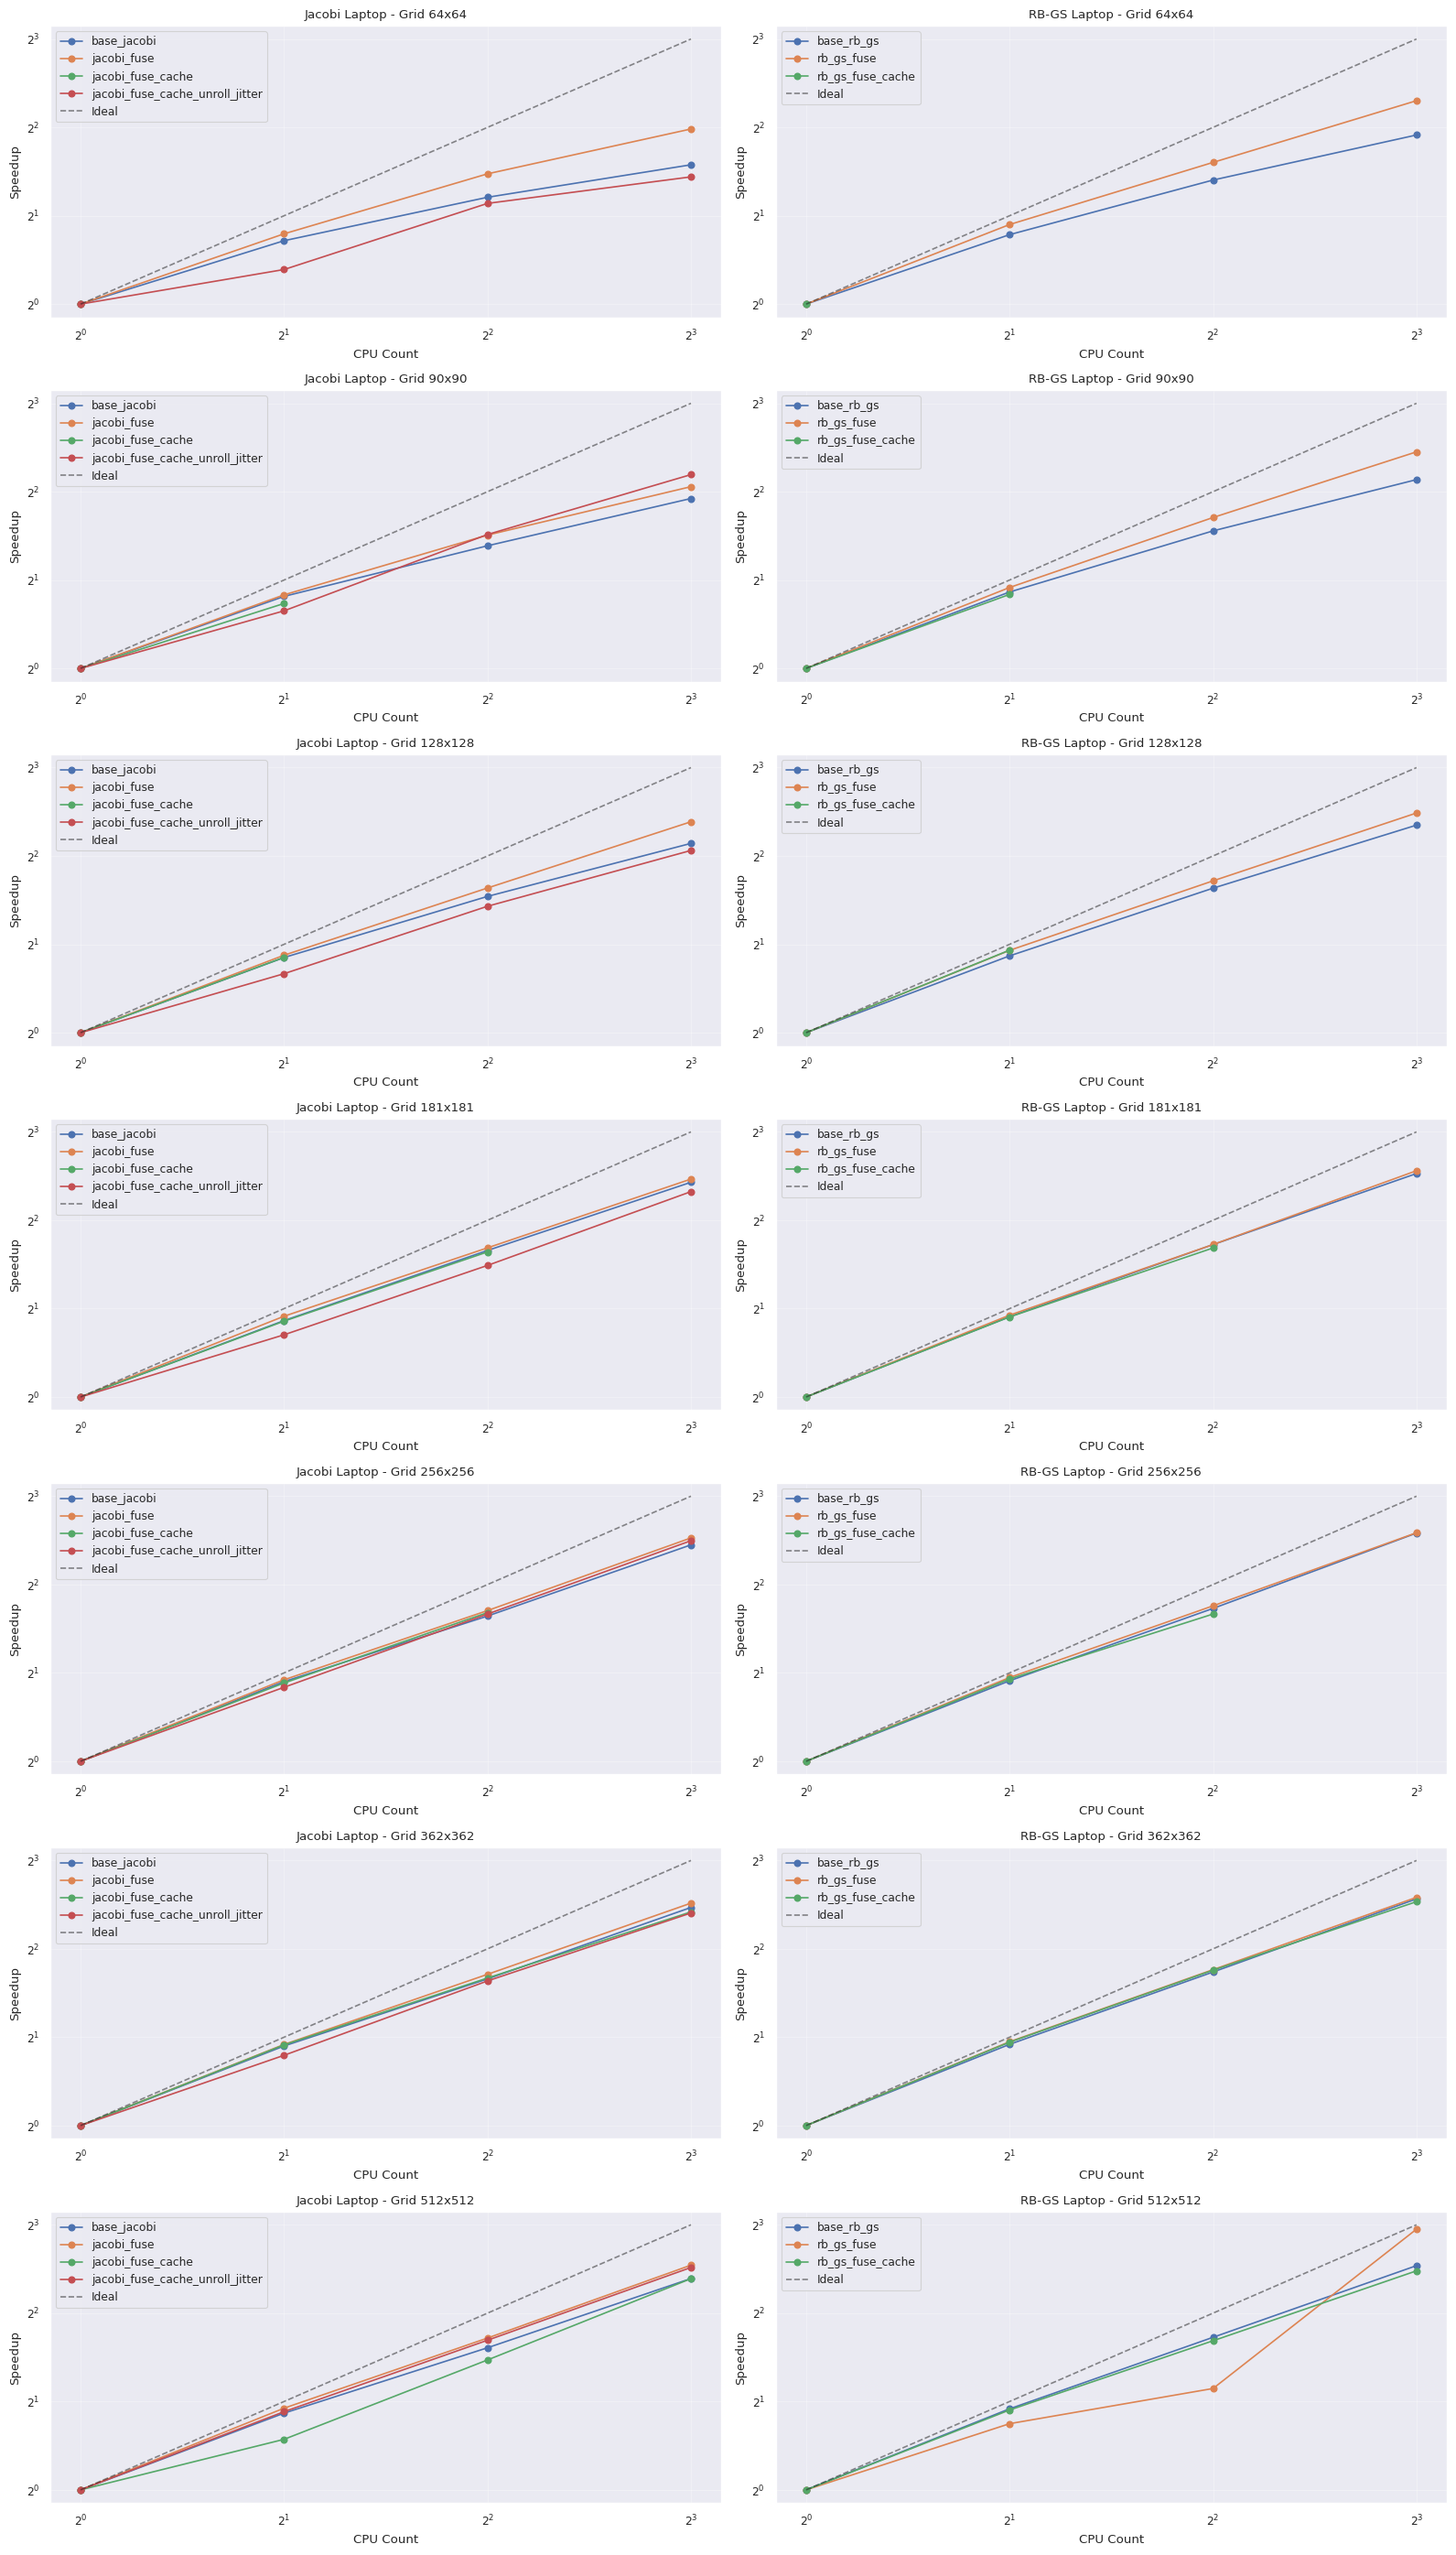

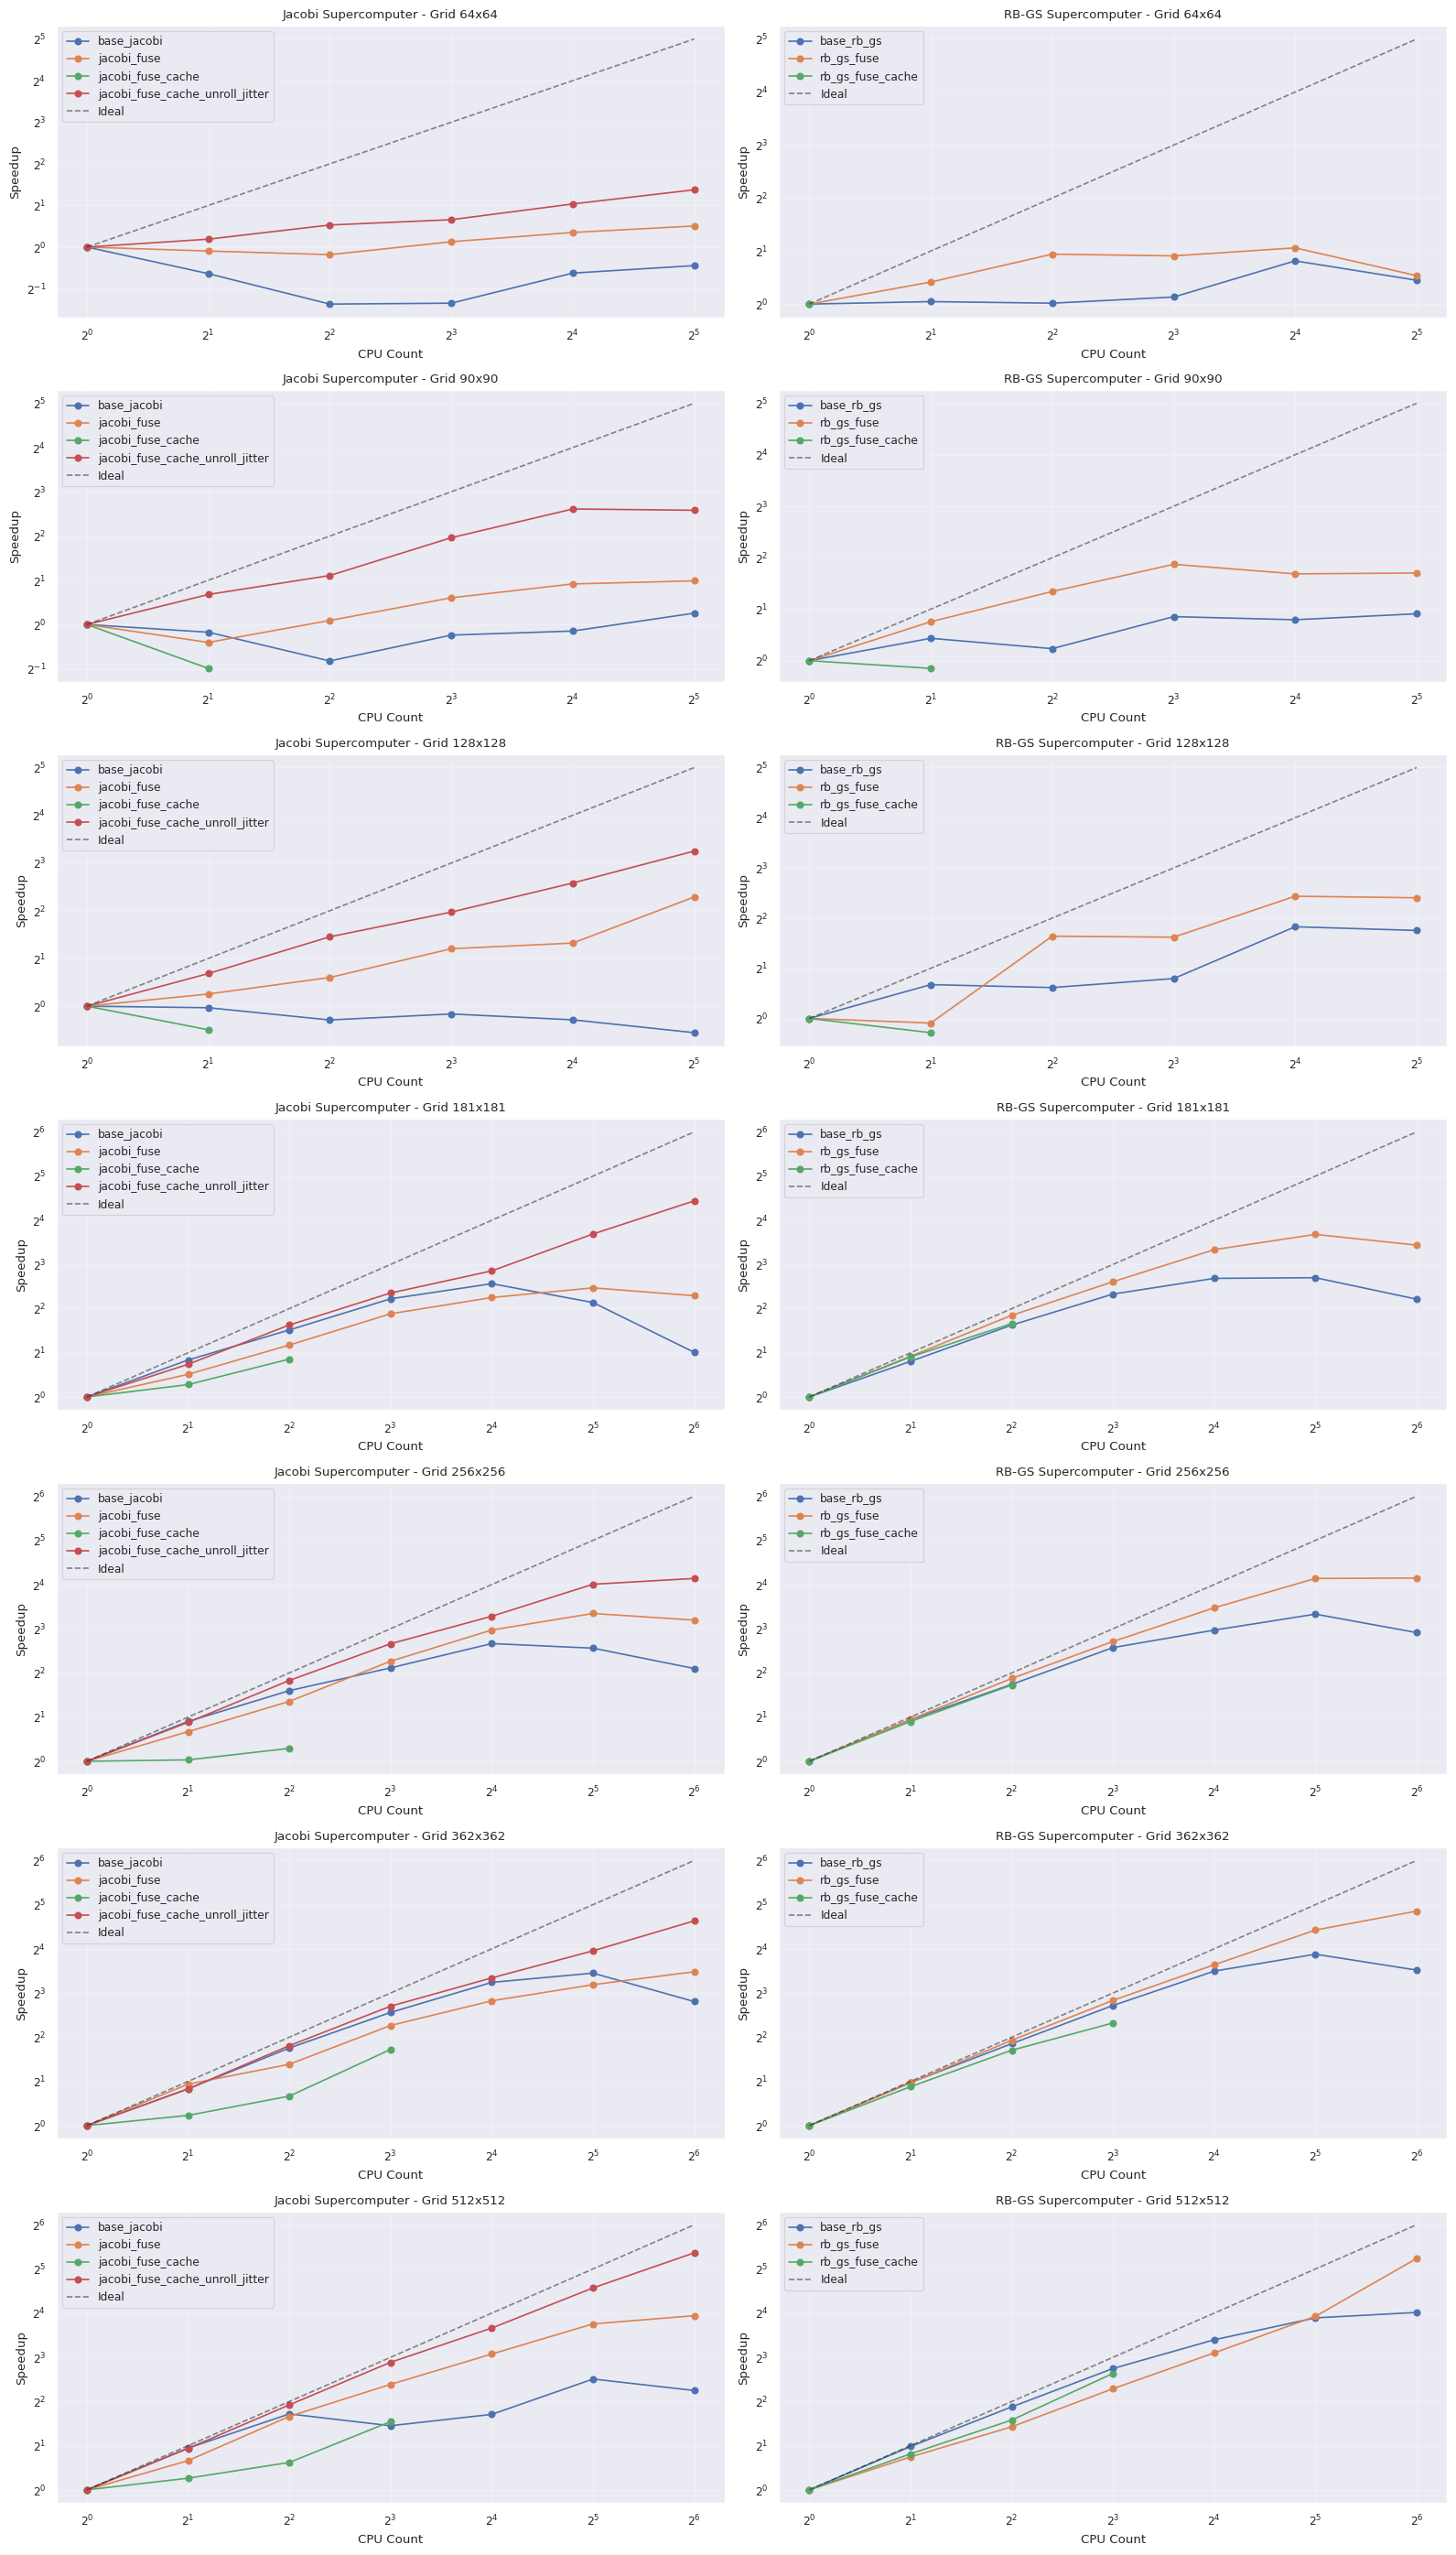

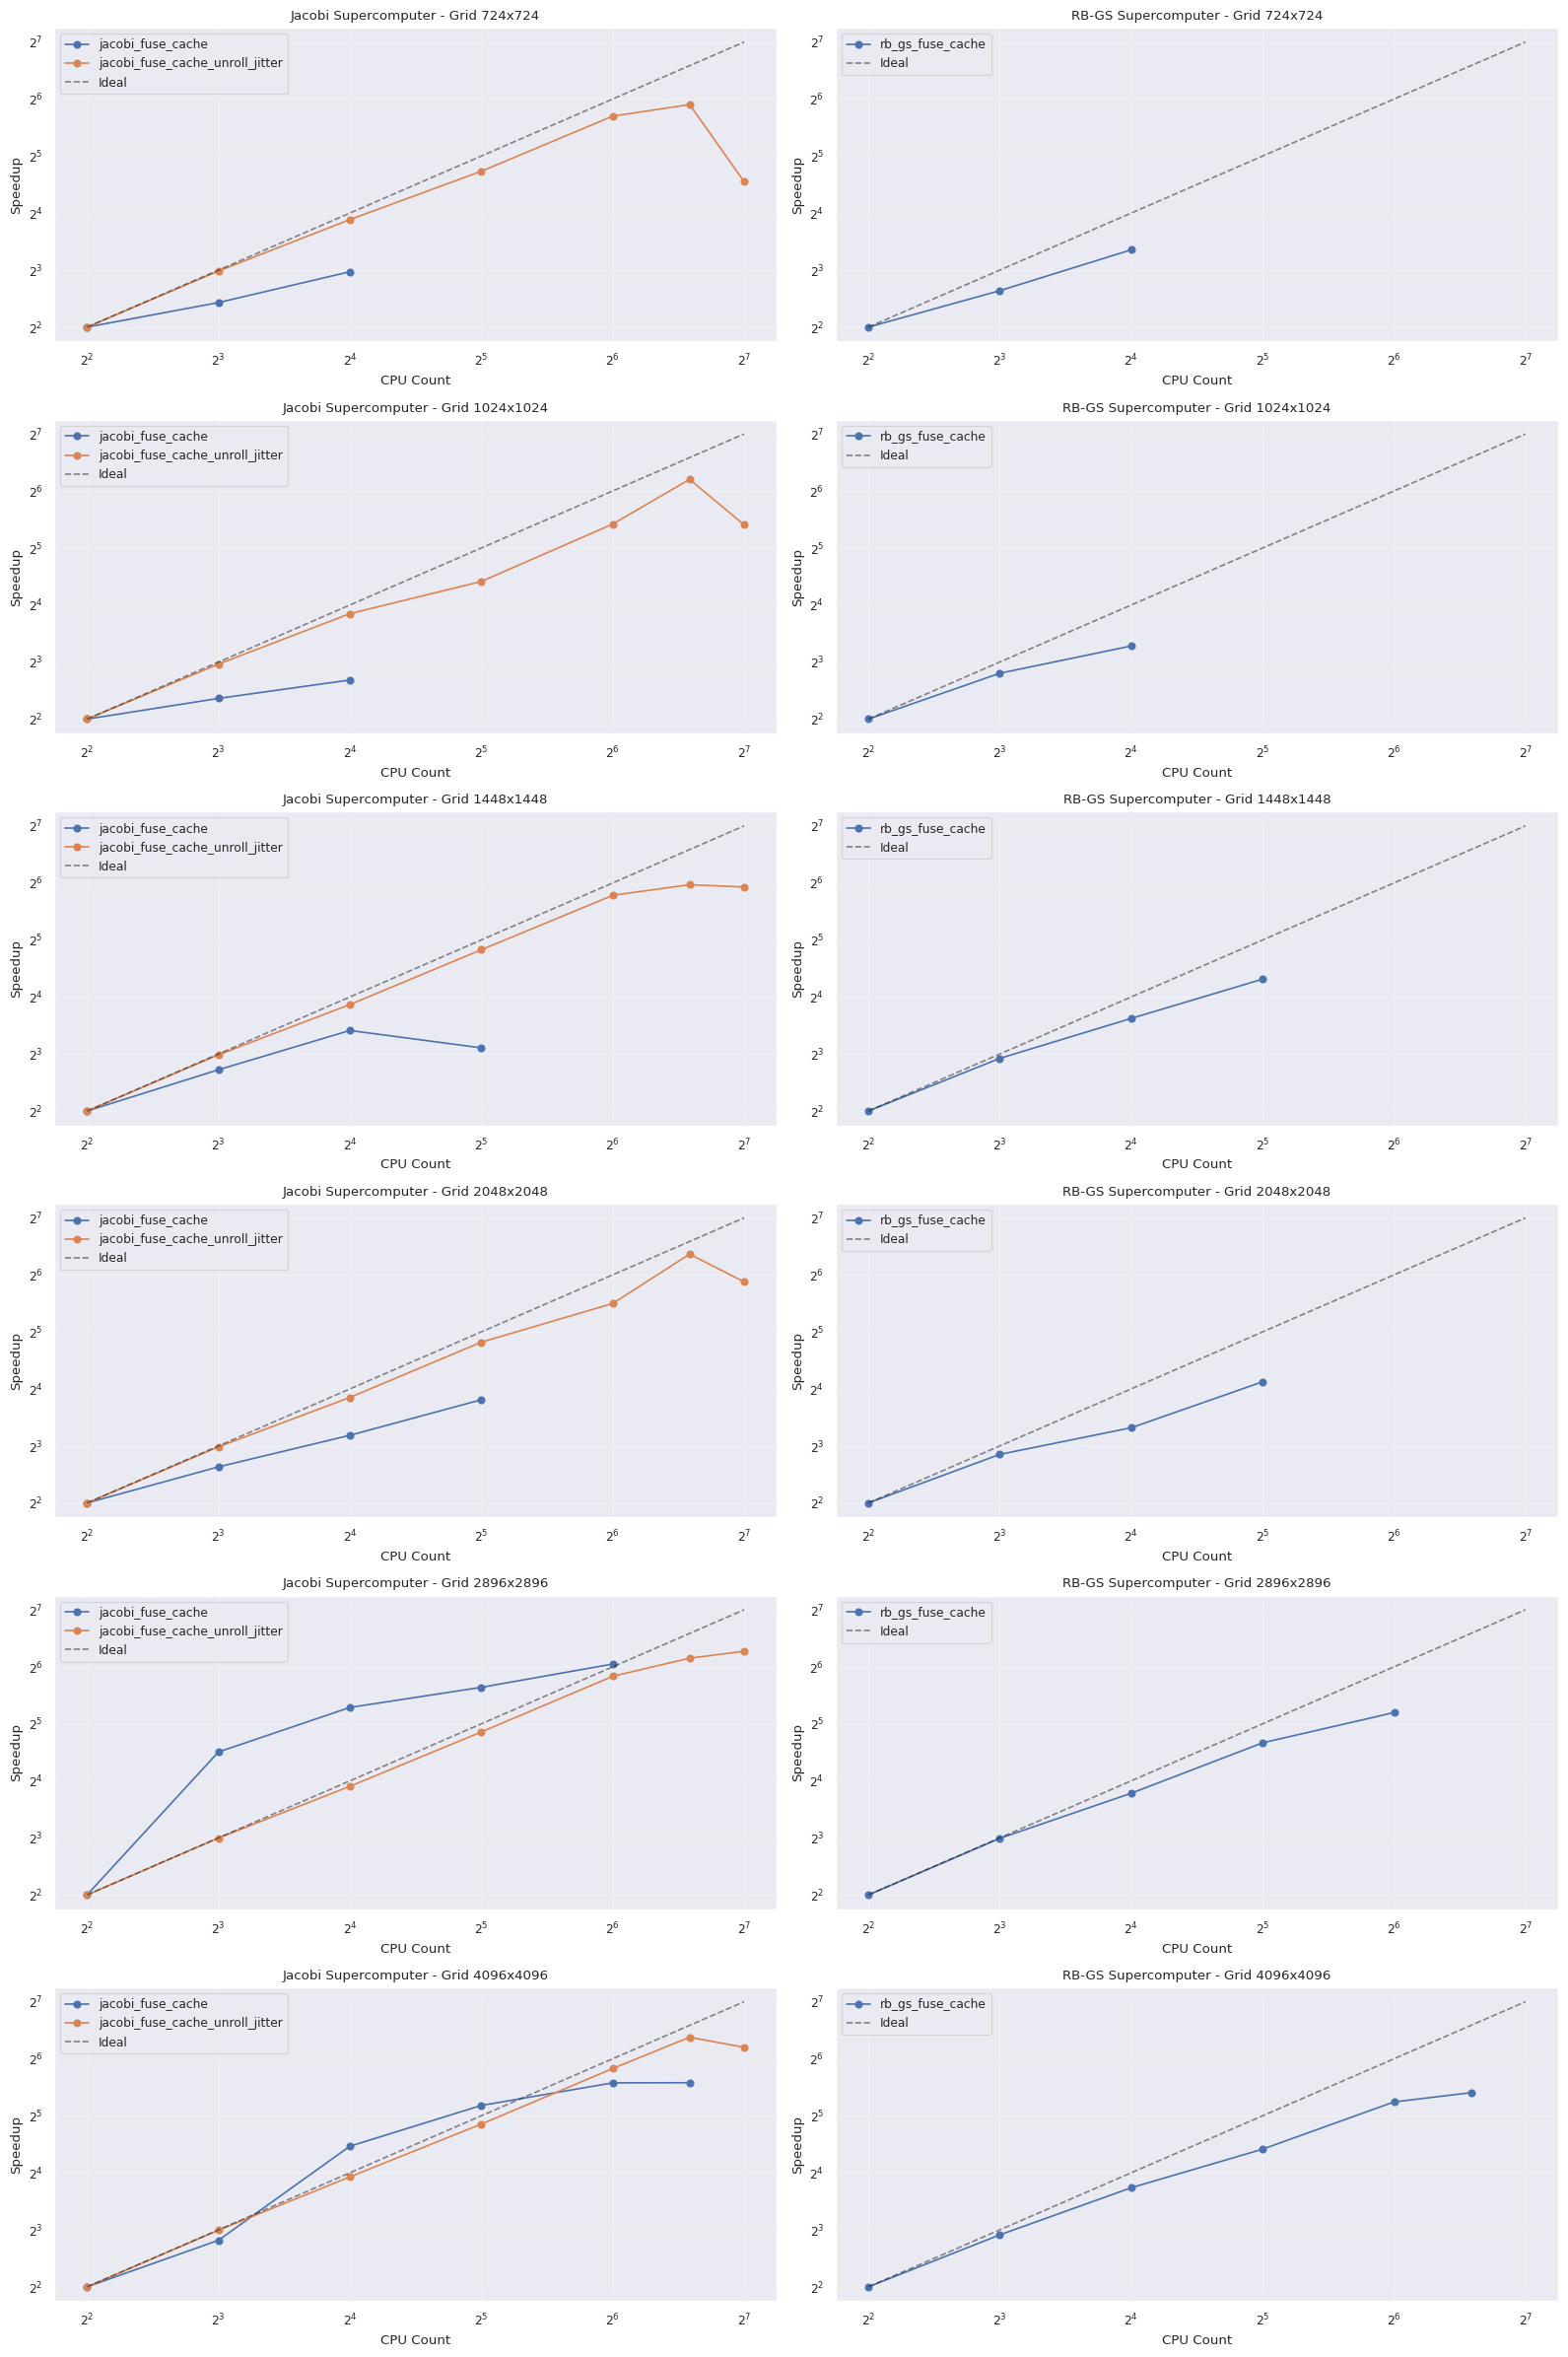

In [81]:
# Filter out the durations
def prepare_scaling_data(joint_df, algo_type, grid_size, platform):
    """
    Prepare data for strong scaling plots

    Parameters:
    - joint_df: complete dataframe
    - algo_type: either 'jacobi' or 'rbgs'
    - grid_size: tuple (nx, ny) or single value
    - platform: 'laptop' or 'supercomputer'

    Returns: dataframe ready for plotting with speedup computed
    """
    # Define modules based on algorithm type
    if algo_type == 'jacobi':
        modules = [
            "base_jacobi",
            "jacobi_fuse",
            "jacobi_fuse_cache",
            "jacobi_fuse_cache_unroll_jitter",
        ]
    else:  # rbgs
        modules = [
            "base_rb_gs",
            "rb_gs_fuse",
            "rb_gs_fuse_cache",
        ]

    # Filter data
    filtered = joint_df[
        (joint_df["device"] == "cpu") &
        (joint_df["module"].isin(modules)) &
        (joint_df["nx"] == grid_size) &
        (joint_df["ny"] == grid_size) &
        (joint_df["platform"] == platform)
    ].copy()

    # Group and compute average duration
    grouped = filtered.groupby(['nx', 'ny', 'module', 'platform', 'cpu_count'])['duration'].mean().reset_index()

    # Compute speedup for each module
    speedup_data = []
    for module in modules:
        subset = grouped[grouped['module'] == module].copy()
        if len(subset) == 0:
            continue

        # Get baseline (minimum cpu_count)
        baseline_cpu = subset['cpu_count'].min()
        baseline_duration = subset[subset['cpu_count'] == baseline_cpu]['duration'].values

        if len(baseline_duration) == 0:
            continue

        baseline_duration = baseline_duration[0]

        # Compute speedup
        subset['speedup'] = baseline_duration / subset['duration']

        # Apply 4x multiplier for grids > 512
        if grid_size > 512:
            subset['speedup'] = subset['speedup'] * 4

        speedup_data.append(subset)

    if len(speedup_data) == 0:
        return None

    return pd.concat(speedup_data, ignore_index=True)

# Grid sizes
small_grids = [64, 90, 128, 181, 256, 362, 512]
large_grids = [724, 1024, 1448, 2048, 2896, 4096]

# Create first figure (small grids - Laptop) - 2 columns
fig1, axes1 = plt.subplots(7, 2, figsize=(16, 28))

for idx, grid_size in enumerate(small_grids):
    # Jacobi - Laptop
    jacobi_laptop = prepare_scaling_data(joint_df, 'jacobi', grid_size, 'laptop')
    if jacobi_laptop is not None:
        for module in jacobi_laptop['module'].unique():
            subset = jacobi_laptop[jacobi_laptop['module'] == module]
            axes1[idx, 0].plot(subset['cpu_count'], subset['speedup'], marker='o', label=module)

        # Add ideal scaling line
        max_cpu = jacobi_laptop['cpu_count'].max()
        min_cpu = jacobi_laptop['cpu_count'].min()
        axes1[idx, 0].plot([min_cpu, max_cpu], [min_cpu, max_cpu], 'k--', alpha=0.5, label='Ideal')

        axes1[idx, 0].set_xscale('log', base=2)
        axes1[idx, 0].set_yscale('log', base=2)
        axes1[idx, 0].set_title(f'Jacobi Laptop - Grid {grid_size}x{grid_size}')
        axes1[idx, 0].set_xlabel('CPU Count')
        axes1[idx, 0].set_ylabel('Speedup')
        axes1[idx, 0].legend()
        axes1[idx, 0].grid(True, alpha=0.3)

    # RB-GS - Laptop
    rbgs_laptop = prepare_scaling_data(joint_df, 'rbgs', grid_size, 'laptop')
    if rbgs_laptop is not None:
        for module in rbgs_laptop['module'].unique():
            subset = rbgs_laptop[rbgs_laptop['module'] == module]
            axes1[idx, 1].plot(subset['cpu_count'], subset['speedup'], marker='o', label=module)

        # Add ideal scaling line
        max_cpu = rbgs_laptop['cpu_count'].max()
        min_cpu = rbgs_laptop['cpu_count'].min()
        axes1[idx, 1].plot([min_cpu, max_cpu], [min_cpu, max_cpu], 'k--', alpha=0.5, label='Ideal')

        axes1[idx, 1].set_xscale('log', base=2)
        axes1[idx, 1].set_yscale('log', base=2)
        axes1[idx, 1].set_title(f'RB-GS Laptop - Grid {grid_size}x{grid_size}')
        axes1[idx, 1].set_xlabel('CPU Count')
        axes1[idx, 1].set_ylabel('Speedup')
        axes1[idx, 1].legend()
        axes1[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
write_fig("091_strong_scaling_small_laptop", fig1)

# Create second figure (small grids - Supercomputer) - 2 columns
fig2, axes2 = plt.subplots(7, 2, figsize=(16, 28))

for idx, grid_size in enumerate(small_grids):
    # Jacobi - Supercomputer
    jacobi_super = prepare_scaling_data(joint_df, 'jacobi', grid_size, 'supercomputer')
    if jacobi_super is not None:
        for module in jacobi_super['module'].unique():
            subset = jacobi_super[jacobi_super['module'] == module]
            axes2[idx, 0].plot(subset['cpu_count'], subset['speedup'], marker='o', label=module)

        # Add ideal scaling line
        max_cpu = jacobi_super['cpu_count'].max()
        min_cpu = jacobi_super['cpu_count'].min()
        axes2[idx, 0].plot([min_cpu, max_cpu], [min_cpu, max_cpu], 'k--', alpha=0.5, label='Ideal')

        axes2[idx, 0].set_xscale('log', base=2)
        axes2[idx, 0].set_yscale('log', base=2)
        axes2[idx, 0].set_title(f'Jacobi Supercomputer - Grid {grid_size}x{grid_size}')
        axes2[idx, 0].set_xlabel('CPU Count')
        axes2[idx, 0].set_ylabel('Speedup')
        axes2[idx, 0].legend()
        axes2[idx, 0].grid(True, alpha=0.3)

    # RB-GS - Supercomputer
    rbgs_super = prepare_scaling_data(joint_df, 'rbgs', grid_size, 'supercomputer')
    if rbgs_super is not None:
        for module in rbgs_super['module'].unique():
            subset = rbgs_super[rbgs_super['module'] == module]
            axes2[idx, 1].plot(subset['cpu_count'], subset['speedup'], marker='o', label=module)

        # Add ideal scaling line
        max_cpu = rbgs_super['cpu_count'].max()
        min_cpu = rbgs_super['cpu_count'].min()
        axes2[idx, 1].plot([min_cpu, max_cpu], [min_cpu, max_cpu], 'k--', alpha=0.5, label='Ideal')

        axes2[idx, 1].set_xscale('log', base=2)
        axes2[idx, 1].set_yscale('log', base=2)
        axes2[idx, 1].set_title(f'RB-GS Supercomputer - Grid {grid_size}x{grid_size}')
        axes2[idx, 1].set_xlabel('CPU Count')
        axes2[idx, 1].set_ylabel('Speedup')
        axes2[idx, 1].legend()
        axes2[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
write_fig("092_strong_scaling_small_supercomputer", fig2)

# Create third figure (large grids - Supercomputer only) - 2 columns
fig3, axes3 = plt.subplots(6, 2, figsize=(16, 24))

for idx, grid_size in enumerate(large_grids):
    # Jacobi - Supercomputer
    jacobi_super = prepare_scaling_data(joint_df, 'jacobi', grid_size, 'supercomputer')
    if jacobi_super is not None:
        for module in jacobi_super['module'].unique():
            subset = jacobi_super[jacobi_super['module'] == module]
            axes3[idx, 0].plot(subset['cpu_count'], subset['speedup'], marker='o', label=module)

        # Add ideal scaling line
        max_cpu = jacobi_super['cpu_count'].max()
        min_cpu = jacobi_super['cpu_count'].min()
        axes3[idx, 0].plot([min_cpu, max_cpu], [min_cpu, max_cpu], 'k--', alpha=0.5, label='Ideal')

        axes3[idx, 0].set_xscale('log', base=2)
        axes3[idx, 0].set_yscale('log', base=2)
        axes3[idx, 0].set_title(f'Jacobi Supercomputer - Grid {grid_size}x{grid_size}')
        axes3[idx, 0].set_xlabel('CPU Count')
        axes3[idx, 0].set_ylabel('Speedup')
        axes3[idx, 0].legend()
        axes3[idx, 0].grid(True, alpha=0.3)

    # RB-GS - Supercomputer
    rbgs_super = prepare_scaling_data(joint_df, 'rbgs', grid_size, 'supercomputer')
    if rbgs_super is not None:
        for module in rbgs_super['module'].unique():
            subset = rbgs_super[rbgs_super['module'] == module]
            axes3[idx, 1].plot(subset['cpu_count'], subset['speedup'], marker='o', label=module)

        # Add ideal scaling line
        max_cpu = rbgs_super['cpu_count'].max()
        min_cpu = rbgs_super['cpu_count'].min()
        axes3[idx, 1].plot([min_cpu, max_cpu], [min_cpu, max_cpu], 'k--', alpha=0.5, label='Ideal')

        axes3[idx, 1].set_xscale('log', base=2)
        axes3[idx, 1].set_yscale('log', base=2)
        axes3[idx, 1].set_title(f'RB-GS Supercomputer - Grid {grid_size}x{grid_size}')
        axes3[idx, 1].set_xlabel('CPU Count')
        axes3[idx, 1].set_ylabel('Speedup')
        axes3[idx, 1].legend()
        axes3[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
write_fig("093_strong_scaling_large_supercomputer", fig3)


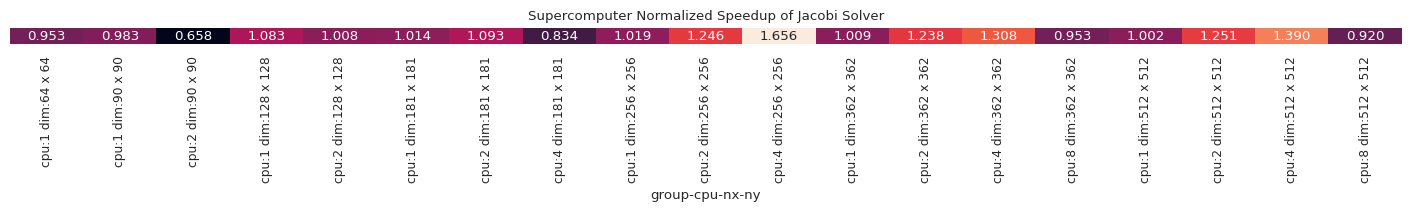

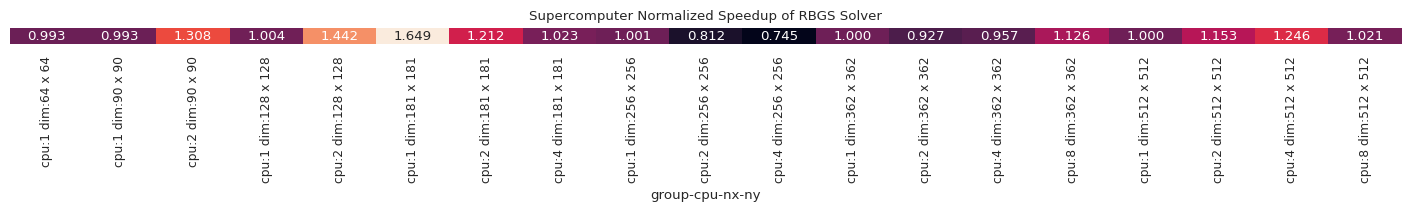

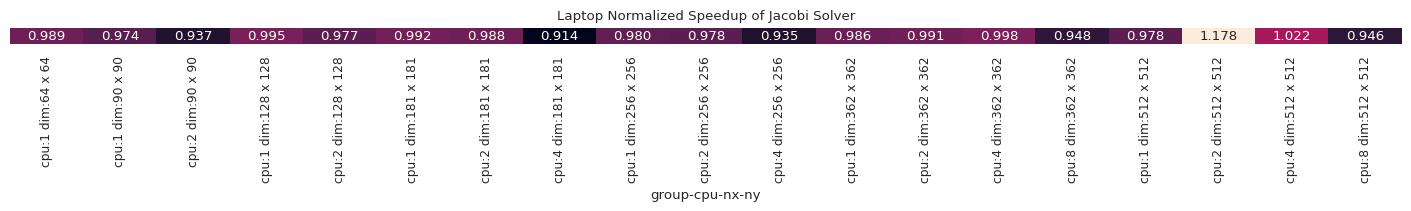

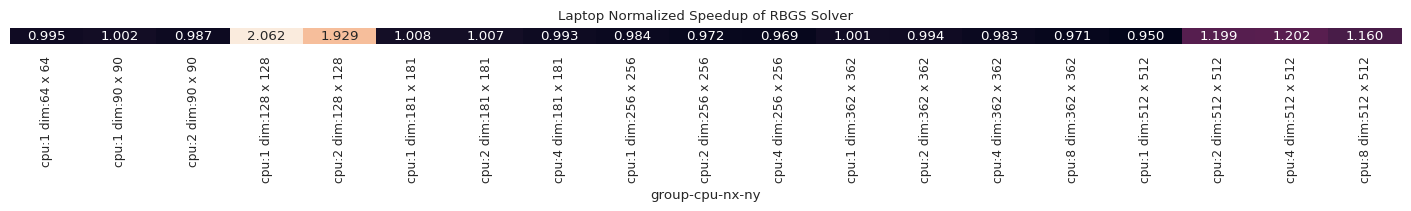

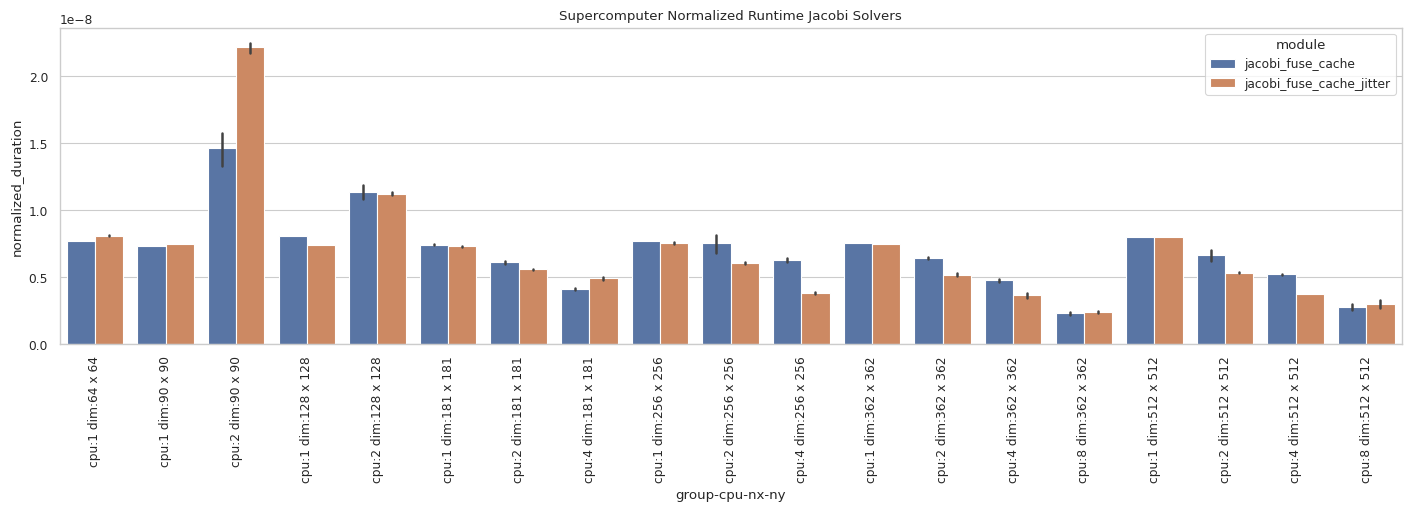

/tmp/ipykernel_6772/819535786.py:202: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


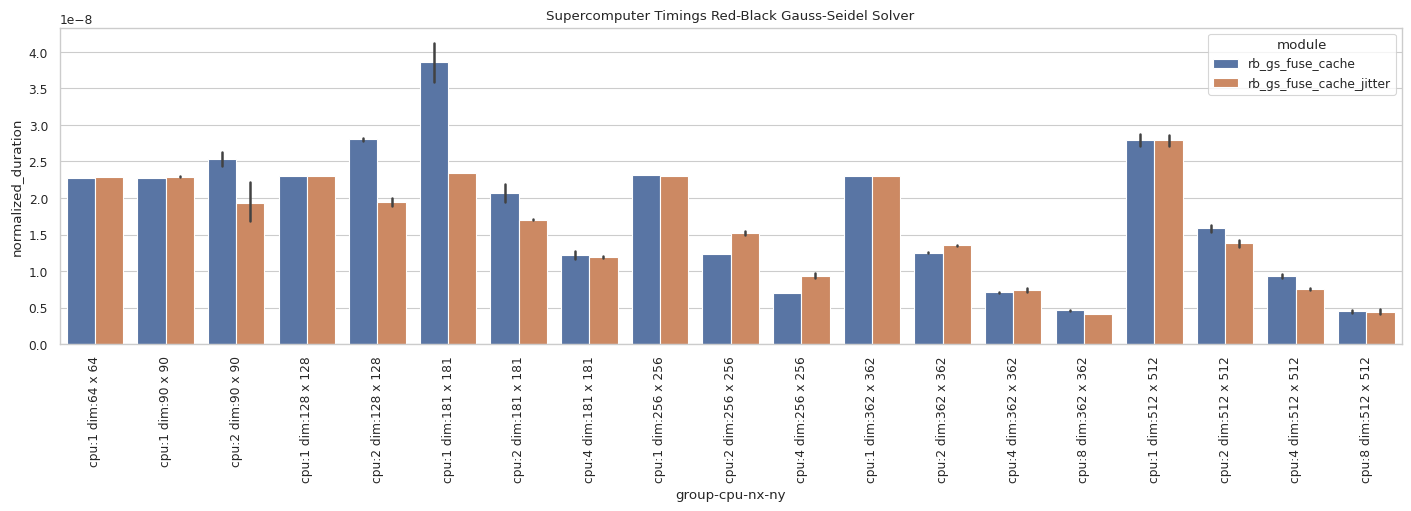

/tmp/ipykernel_6772/819535786.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


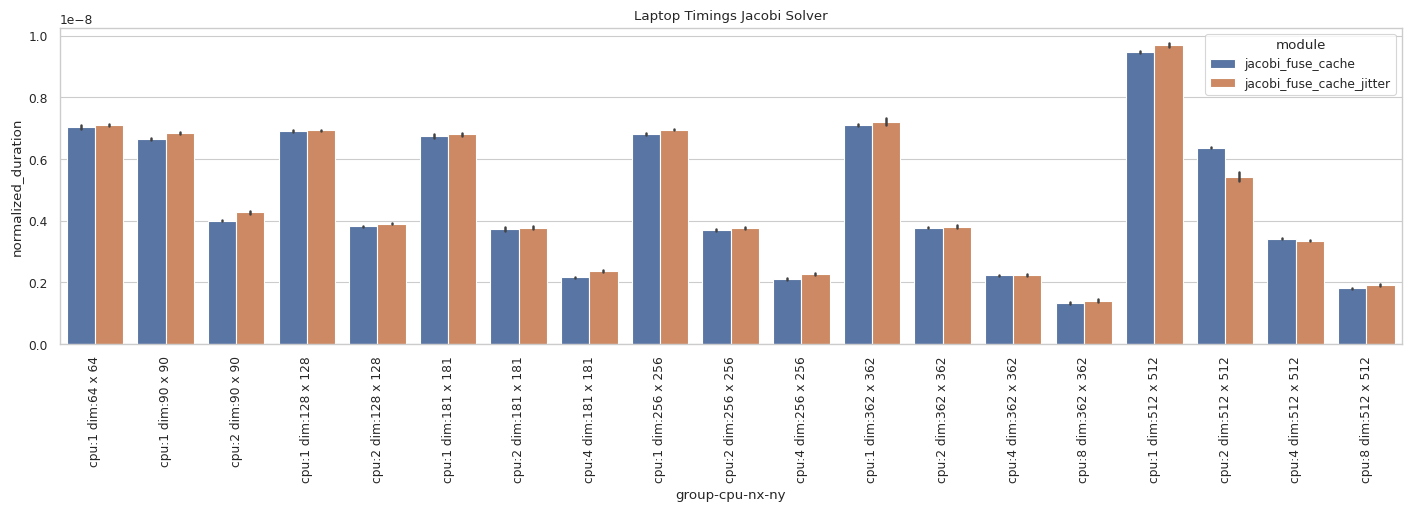

/tmp/ipykernel_6772/819535786.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


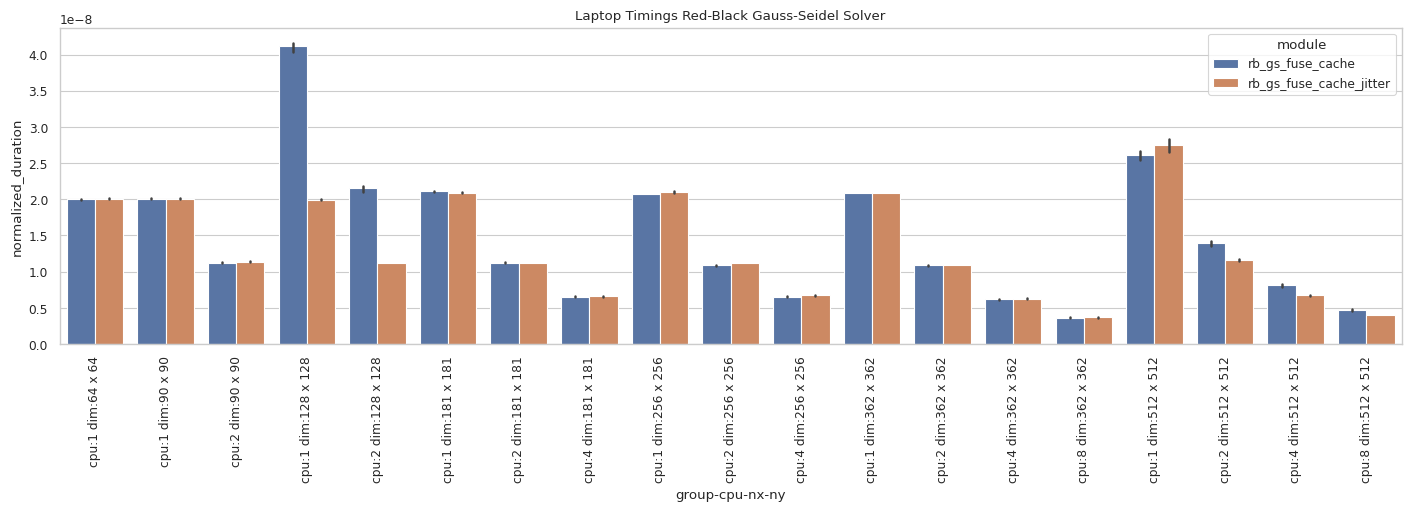

In [15]:
# Filter out the durations
jitter_set_jacobi = joint_df[joint_df["module"].isin(["jacobi_fuse_cache", "jacobi_fuse_cache_jitter"])]
j_jacobi_sc = jitter_set_jacobi[jitter_set_jacobi["benchmark_name"].isin(["cpu_small_supercomputer", "cpu_medium_supercomputer"])].dropna(subset=["normalized_duration", "duration"]).sort_values(["nx", "ny", "cpu_count"])

jitter_set_rbgs = joint_df[joint_df["module"].isin(["rb_gs_fuse_cache", "rb_gs_fuse_cache_jitter"])]
j_rbgs_sc = jitter_set_rbgs[jitter_set_rbgs["benchmark_name"].isin(["cpu_small_supercomputer", "cpu_medium_supercomputer"])].dropna(subset=["normalized_duration", "duration"]).sort_values(["nx", "ny", "cpu_count"])

jitter_set_jacobi = joint_df[joint_df["module"].isin(["jacobi_fuse_cache", "jacobi_fuse_cache_jitter"])]
j_jacobi_lt = jitter_set_jacobi[jitter_set_jacobi["benchmark_name"].isin(["cpu_small_laptop", "cpu_medium_laptop"])].dropna(subset=["normalized_duration", "duration"]).sort_values(["nx", "ny", "cpu_count"])

jitter_set_rbgs = joint_df[joint_df["module"].isin(["rb_gs_fuse_cache", "rb_gs_fuse_cache_jitter"])]
j_rbgs_lt = jitter_set_rbgs[jitter_set_rbgs["benchmark_name"].isin(["cpu_small_laptop", "cpu_medium_laptop"])].dropna(subset=["normalized_duration", "duration"]).sort_values(["nx", "ny", "cpu_count"])

# ---------------------------------------------------------
# 071 — Jacobi Supercomputer jitter speedup heatmap
# ---------------------------------------------------------
# Speedup - aggregate first
aggregated_jacobi_sc = j_jacobi_sc.groupby(['group-cpu-nx-ny', 'module'])['normalized_duration'].mean().reset_index()
sort_info_jacobi_sc = j_jacobi_sc[['group-cpu-nx-ny', 'nx', 'ny', 'cpu_count']].drop_duplicates()
aggregated_jacobi_sc = aggregated_jacobi_sc.merge(sort_info_jacobi_sc, on='group-cpu-nx-ny')

pivoted_jacobi_sc = aggregated_jacobi_sc.pivot(index='group-cpu-nx-ny',
                                               columns='module',
                                               values='normalized_duration')
pivoted_jacobi_sc = pivoted_jacobi_sc.merge(sort_info_jacobi_sc, on='group-cpu-nx-ny')
pivoted_jacobi_sc = pivoted_jacobi_sc.sort_values(['nx', 'ny', 'cpu_count'])

pivoted_jacobi_sc['jitter_ratio'] = (
        pivoted_jacobi_sc['jacobi_fuse_cache'] /
        pivoted_jacobi_sc['jacobi_fuse_cache_jitter']
)

heatmap_jacobi_sc = pivoted_jacobi_sc.set_index('group-cpu-nx-ny')[['jitter_ratio']].T

with sns.axes_style("whitegrid"):

    fig, ax = plt.subplots(figsize=(14, 2), constrained_layout=True)

    ax.set_title('Supercomputer Normalized Speedup of Jacobi Solver')
    ax.set_ylabel('Normalized Speedup (no jitter / jitter)')

    hm = sns.heatmap(
        heatmap_jacobi_sc,
        annot=True,
        fmt='.3f',
        cbar=False,
        xticklabels=True,
        yticklabels=False,
        ax=ax
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    write_fig("071_jitter_speedup_jacobi_supercomputer", fig)
    plt.show()

# ---------------------------------------------------------
# 072 — RBGS Supercomputer jitter speedup heatmap
# ---------------------------------------------------------
# Same method as Jacobi
aggregated_rbgs_sc = j_rbgs_sc.groupby(['group-cpu-nx-ny', 'module'])['normalized_duration'].mean().reset_index()
sort_info_rbgs_sc = j_rbgs_sc[['group-cpu-nx-ny', 'nx', 'ny', 'cpu_count']].drop_duplicates()
aggregated_rbgs_sc = aggregated_rbgs_sc.merge(sort_info_rbgs_sc, on='group-cpu-nx-ny')

pivoted_rbgs_sc = aggregated_rbgs_sc.pivot(index='group-cpu-nx-ny',
                                           columns='module',
                                           values='normalized_duration')
pivoted_rbgs_sc = pivoted_rbgs_sc.merge(sort_info_rbgs_sc, on='group-cpu-nx-ny')
pivoted_rbgs_sc = pivoted_rbgs_sc.sort_values(['nx', 'ny', 'cpu_count'])

pivoted_rbgs_sc['jitter_ratio'] = (
    pivoted_rbgs_sc['rb_gs_fuse_cache'] /
    pivoted_rbgs_sc['rb_gs_fuse_cache_jitter']
)

heatmap_rbgs_sc = pivoted_rbgs_sc.set_index('group-cpu-nx-ny')[['jitter_ratio']].T

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(14, 2), constrained_layout=True)

    ax.set_title("Supercomputer Normalized Speedup of RBGS Solver")
    ax.set_ylabel("Normalized Speedup (no jitter / jitter)")

    sns.heatmap(
        heatmap_rbgs_sc,
        annot=True,
        fmt='.3f',
        cbar=False,
        xticklabels=True,
        yticklabels=False,
        ax=ax
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    write_fig("072_jitter_speedup_rbgs_supercomputer", fig)
    plt.show()


# ---------------------------------------------------------
# 073 — Jacobi Laptop jitter speedup heatmap
# ---------------------------------------------------------
aggregated_jacobi_lt = j_jacobi_lt.groupby(['group-cpu-nx-ny', 'module'])['normalized_duration'].mean().reset_index()
sort_info_jacobi_lt = j_jacobi_lt[['group-cpu-nx-ny', 'nx', 'ny', 'cpu_count']].drop_duplicates()
aggregated_jacobi_lt = aggregated_jacobi_lt.merge(sort_info_jacobi_lt, on='group-cpu-nx-ny')

pivoted_jacobi_lt = aggregated_jacobi_lt.pivot(index='group-cpu-nx-ny',
                                               columns='module',
                                               values='normalized_duration')
pivoted_jacobi_lt = pivoted_jacobi_lt.merge(sort_info_jacobi_lt, on='group-cpu-nx-ny')
pivoted_jacobi_lt = pivoted_jacobi_lt.sort_values(['nx', 'ny', 'cpu_count'])

pivoted_jacobi_lt['jitter_ratio'] = (
    pivoted_jacobi_lt['jacobi_fuse_cache'] /
    pivoted_jacobi_lt['jacobi_fuse_cache_jitter']
)

heatmap_jacobi_lt = pivoted_jacobi_lt.set_index('group-cpu-nx-ny')[['jitter_ratio']].T

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(14, 2), constrained_layout=True)

    ax.set_title("Laptop Normalized Speedup of Jacobi Solver")
    ax.set_ylabel("Normalized Speedup (no jitter / jitter)")

    sns.heatmap(
        heatmap_jacobi_lt,
        annot=True,
        fmt='.3f',
        cbar=False,
        xticklabels=True,
        yticklabels=False,
        ax=ax
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    write_fig("073_jitter_speedup_jacobi_laptop", fig)
    plt.show()


# ---------------------------------------------------------
# 074 — RBGS Laptop jitter speedup heatmap
# ---------------------------------------------------------
aggregated_rbgs_lt = j_rbgs_lt.groupby(['group-cpu-nx-ny', 'module'])['normalized_duration'].mean().reset_index()
sort_info_rbgs_lt = j_rbgs_lt[['group-cpu-nx-ny', 'nx', 'ny', 'cpu_count']].drop_duplicates()
aggregated_rbgs_lt = aggregated_rbgs_lt.merge(sort_info_rbgs_lt, on='group-cpu-nx-ny')

pivoted_rbgs_lt = aggregated_rbgs_lt.pivot(index='group-cpu-nx-ny',
                                           columns='module',
                                           values='normalized_duration')
pivoted_rbgs_lt = pivoted_rbgs_lt.merge(sort_info_rbgs_lt, on='group-cpu-nx-ny')
pivoted_rbgs_lt = pivoted_rbgs_lt.sort_values(['nx', 'ny', 'cpu_count'])

pivoted_rbgs_lt['jitter_ratio'] = (
    pivoted_rbgs_lt['rb_gs_fuse_cache'] /
    pivoted_rbgs_lt['rb_gs_fuse_cache_jitter']
)

heatmap_rbgs_lt = pivoted_rbgs_lt.set_index('group-cpu-nx-ny')[['jitter_ratio']].T

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(14, 2), constrained_layout=True)

    ax.set_title("Laptop Normalized Speedup of RBGS Solver")
    ax.set_ylabel("Normalized Speedup (no jitter / jitter)")

    sns.heatmap(
        heatmap_rbgs_lt,
        annot=True,
        fmt='.3f',
        cbar=False,
        xticklabels=True,
        yticklabels=False,
        ax=ax
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    write_fig("074_jitter_speedup_rbgs_laptop", fig)
    plt.show()

# ---------------------------------------------------------
# 075 — RBGS Supercomputer timings bar plot
# ---------------------------------------------------------
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

    # Bar plot
    plt.xticks(rotation=90)
    plt.title('Supercomputer Normalized Runtime Jacobi Solvers')
    sns.barplot(data=j_jacobi_sc, x="group-cpu-nx-ny", y="normalized_duration", hue="module")
    write_fig("075_jitter_timings_jacobi_supercomputer", fig)
    plt.show()

# ---------------------------------------------------------
# 076 — RBGS Supercomputer timings bar plot
# ---------------------------------------------------------
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

    ax.set_title("Supercomputer Timings Red-Black Gauss-Seidel Solver")
    sns.barplot(data=j_rbgs_sc, x="group-cpu-nx-ny",
                y="normalized_duration", hue="module", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    write_fig("076_jitter_timings_rbgs_supercomputer", fig)
    plt.show()


# ---------------------------------------------------------
# 077 — Jacobi Laptop timings bar plot
# ---------------------------------------------------------
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

    ax.set_title("Laptop Timings Jacobi Solver")
    sns.barplot(data=j_jacobi_lt, x="group-cpu-nx-ny",
                y="normalized_duration", hue="module", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    write_fig("077_jitter_timings_jacobi_laptop", fig)
    plt.show()


# ---------------------------------------------------------
# 078 — RBGS Laptop timings bar plot
# ---------------------------------------------------------
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

    ax.set_title("Laptop Timings Red-Black Gauss-Seidel Solver")
    sns.barplot(data=j_rbgs_lt, x="group-cpu-nx-ny",
                y="normalized_duration", hue="module", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    write_fig("078_jitter_timings_rbgs_laptop", fig)
    plt.show()



In [16]:
# ---------------------------------------------------------
# 079 — Combined jitter speedup heatmap (Jacobi/RBGS × Laptop/Supercomputer)
# ---------------------------------------------------------

# Helper: add solver + platform row label
def add_label(df, label):
    df = df.copy()
    df["row_label"] = label
    return df

# Extract the speedup columns from your existing pivoted frames
jacobi_sc_df = pivoted_jacobi_sc[["group-cpu-nx-ny", "jitter_ratio"]]
jacobi_sc_df = add_label(jacobi_sc_df, "Jacobi Supercomputer")

rbgs_sc_df = pivoted_rbgs_sc[["group-cpu-nx-ny", "jitter_ratio"]]
rbgs_sc_df = add_label(rbgs_sc_df, "Red-Black Gauss-Seidel Supercomputer")

jacobi_lt_df = pivoted_jacobi_lt[["group-cpu-nx-ny", "jitter_ratio"]]
jacobi_lt_df = add_label(jacobi_lt_df, "Jacobi Laptop")

rbgs_lt_df = pivoted_rbgs_lt[["group-cpu-nx-ny", "jitter_ratio"]]
rbgs_lt_df = add_label(rbgs_lt_df, "Red-Black Gauss-Seidel Supercomputer")

# Merge all four
combined = pd.concat([
    jacobi_sc_df,
    rbgs_sc_df,
    jacobi_lt_df,
    rbgs_lt_df
], axis=0)

# Sort x-axis using the full sort order from supercomputer Jacobi (same keys apply everywhere)
# Use Jacobi supercomputer sorting info (contains full mapping)
sort_info_global = pd.concat([
    j_jacobi_sc[["group-cpu-nx-ny", "nx", "ny", "cpu_count"]],
    j_rbgs_sc[["group-cpu-nx-ny", "nx", "ny", "cpu_count"]],
    j_jacobi_lt[["group-cpu-nx-ny", "nx", "ny", "cpu_count"]],
    j_rbgs_lt[["group-cpu-nx-ny", "nx", "ny", "cpu_count"]],
]).drop_duplicates()

sort_info_global = sort_info_global.sort_values(["nx", "ny", "cpu_count"])



sort_info = sort_info_jacobi_sc[["group-cpu-nx-ny", "nx", "ny", "cpu_count"]].drop_duplicates()

# merge global sort info
combined = combined.merge(sort_info_global, on="group-cpu-nx-ny", how="left")

# sort by global order
combined = combined.sort_values(["nx", "ny", "cpu_count"])
# Pivot to heatmap shape: 4 rows × N columns
heatmap_all = combined.pivot(index="row_label",
                             columns="group-cpu-nx-ny",
                             values="jitter_ratio")

heatmap_all = heatmap_all.reindex(columns=sort_info_global["group-cpu-nx-ny"])

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(14, 3), constrained_layout=True)

    ax.set_title("Combined Normalized Speedup (no jitter / jitter)")
    sns.heatmap(
        heatmap_all,
        annot=True,
        fmt=".3f",
        cbar=True,
        xticklabels=True,
        yticklabels=True,
        ax=ax
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    plt.ylabel(None)
    write_fig("079_jitter_speedup_all", fig)
    plt.show()

ValueError: Index contains duplicate entries, cannot reshape